In [21]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import pickle
from tqdm import tqdm

In [3]:
%load_ext autoreload
%autoreload 2
import helper_functions as fx
import trade_functions as tf
import parse_histdata

In [3]:
parse_histdata.clean_data()

Replacing 1 rows with non-positive close prices with 0
Replacing 1 rows with close prices above 3.1232 with 1.5616
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 1.8446 with 0.9223
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 296.406 with 148.203
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 4.0662 with 2.0331
Found 600 rows with duplicate DateTime entries
Keeping only last values for each duplicate DateTime entry
Replacing 0 rows with non-positive close prices with 0
Replacing 0 rows with close prices above 3.5356 with 1.7678

In [4]:
file_path = '/Volumes/SEAGATE/FX_data/FX_histdata/'
fx_pairs = ["EURUSD", "EURGBP", "USDJPY", "GBPUSD", "USDCHF", "USDCAD", "AUDUSD", "NZDUSD", "EURJPY", "GBPJPY", "EURCHF", "AUDJPY", "EURAUD", "GBPAUD"]
intervals = ['1T', '5T', '10T', '15T', '30T', '1H', '3H', '6H', '1D']

In [5]:
timeline_df = parse_histdata.timeline_info(fx_pairs)
display(timeline_df)

,Pair,Start,End,Missing Minutes,Max Missing Minutes,Percentage Missing
0,EURUSD,2001-01,2023-12,305633,15547.0,2.527773
1,EURGBP,2002-03,2023-12,388973,5882.0,3.388823
2,USDJPY,2000-05,2023-12,376567,15548.0,3.036179
3,GBPUSD,2000-05,2023-12,345669,15546.0,2.787056
4,USDCHF,2000-05,2023-12,337047,19091.0,2.717530
5,USDCAD,2000-06,2023-12,505296,216573.0,4.080162
6,AUDUSD,2000-06,2023-12,417251,79473.0,3.366455
7,NZDUSD,2005-08,2023-12,301344,5883.0,3.117335
8,EURJPY,2002-03,2023-12,129127,5882.0,1.124984
9,GBPJPY,2002-05,2023-12,93632,13059.0,0.821788


### Test period : 2018-2023 (walk-forward validation)
### Training period : start - 2010 ()

* Initial Training period has only been set upto 2010, due to computational and time constraints.
* Rolling calibration will be from 2011.

Plan to use LSTM to explore pair trading between currency pairs


In [ ]:
fx.create_interval_datasets(fx_pairs, intervals, file_path)

Creating 1T datasets for all pairs
Processing EURUSD for 1T interval
Creating 1T dataset for EURUSD
Processing EURGBP for 1T interval
Creating 1T dataset for EURGBP
Processing USDJPY for 1T interval
Creating 1T dataset for USDJPY
Processing GBPUSD for 1T interval
Creating 1T dataset for GBPUSD
Processing USDCHF for 1T interval
Creating 1T dataset for USDCHF
Processing USDCAD for 1T interval
Creating 1T dataset for USDCAD
Processing AUDUSD for 1T interval
Creating 1T dataset for AUDUSD
Processing NZDUSD for 1T interval
Creating 1T dataset for NZDUSD
Processing EURJPY for 1T interval
Creating 1T dataset for EURJPY
Processing GBPJPY for 1T interval
Creating 1T dataset for GBPJPY
Processing EURCHF for 1T interval
Creating 1T dataset for EURCHF
Processing AUDJPY for 1T interval
Creating 1T dataset for AUDJPY
Processing EURAUD for 1T interval
Creating 1T dataset for EURAUD
Processing GBPAUD for 1T interval
Creating 1T dataset for GBPAUD
Creating 5T datasets for all pairs
Processing EURUSD fo

In the code above, following interpretation has been used:
For Datetime t, the data represents the period from t-1 (included) up till t (not included)
Hence while resampling, (label=right, closed=right) have been used.

In [13]:
fx.calculate_returns(fx_pairs, intervals, file_path)

Calculating returns for 1T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 5T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 10T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 15T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 30T interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 1H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/14...
7/14...
8/14...
9/14...
10/14...
11/14...
12/14...
13/14...
14/14...
Calculating returns for 3H interval
1/14...
2/14...
3/14...
4/14...
5/14...
6/1

Plotting returns distribution for 1T interval


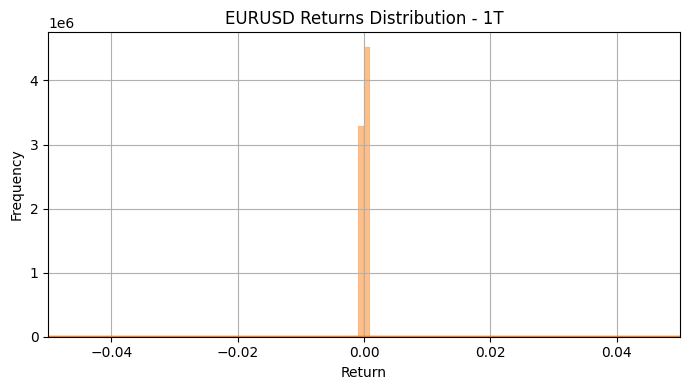

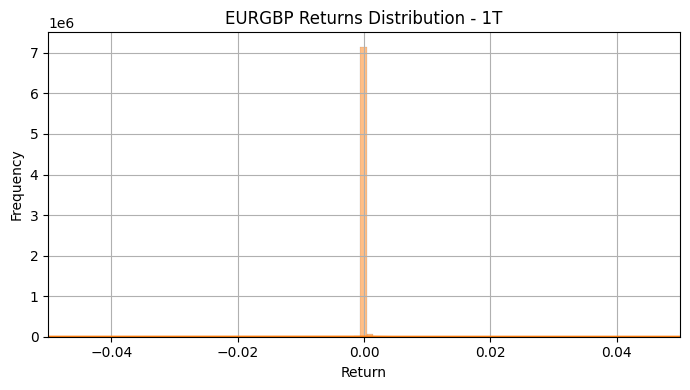

Plotting returns distribution for 5T interval


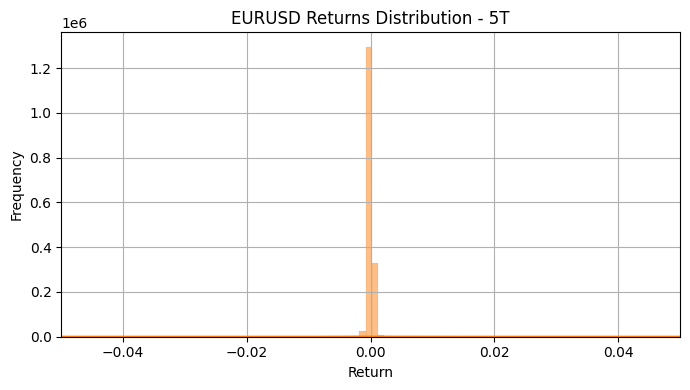

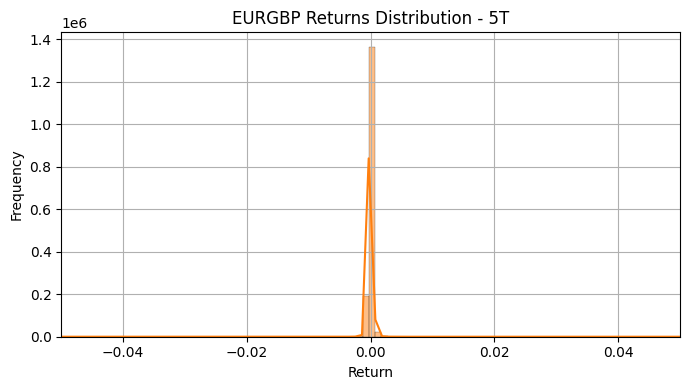

Plotting returns distribution for 10T interval


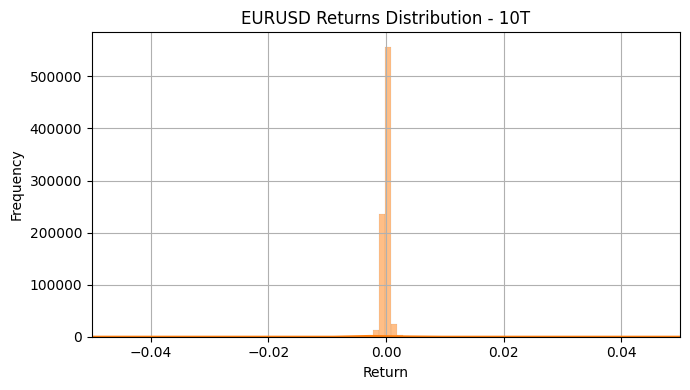

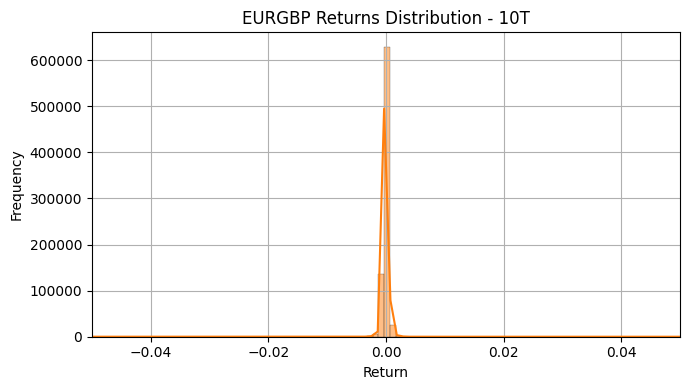

Plotting returns distribution for 15T interval


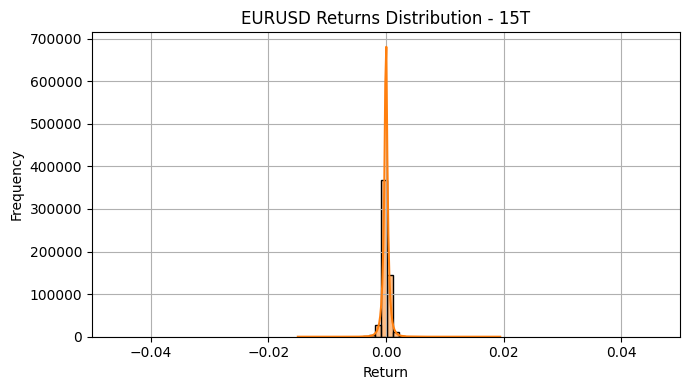

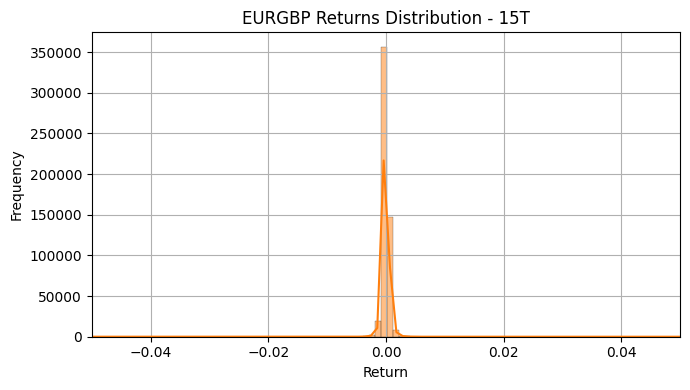

Plotting returns distribution for 30T interval


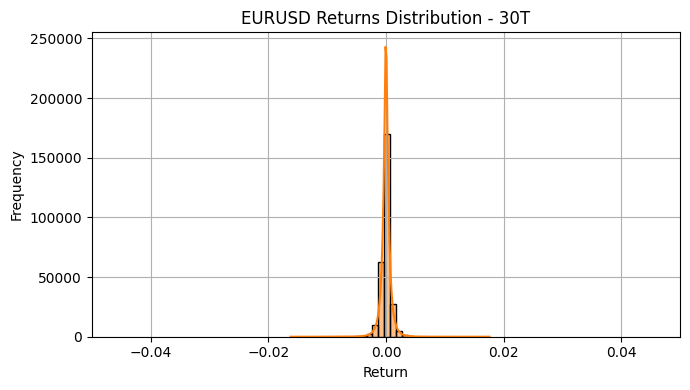

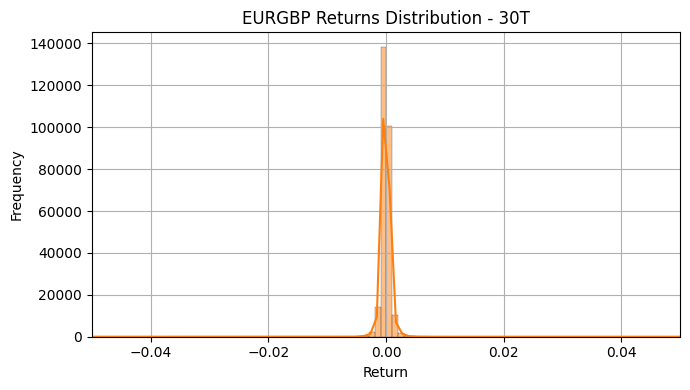

Plotting returns distribution for 1H interval


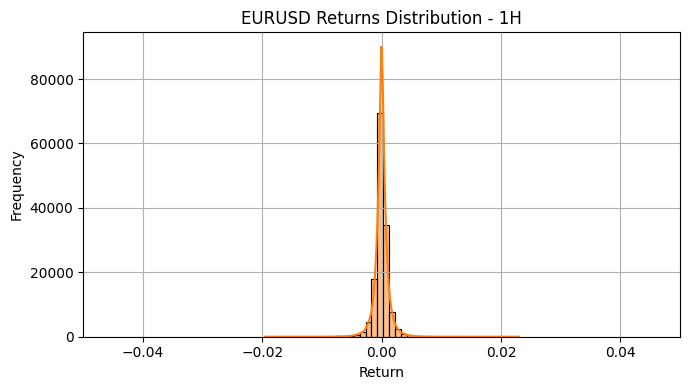

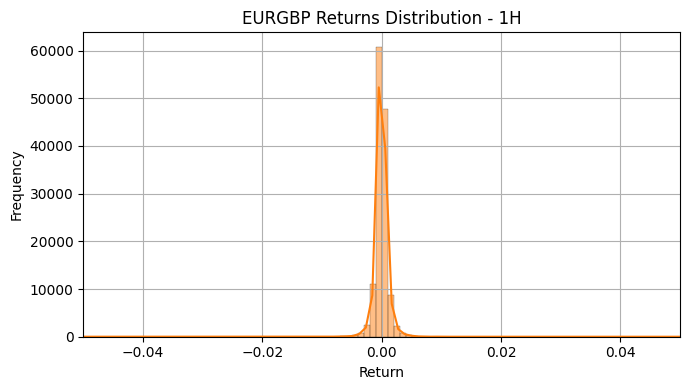

Plotting returns distribution for 3H interval


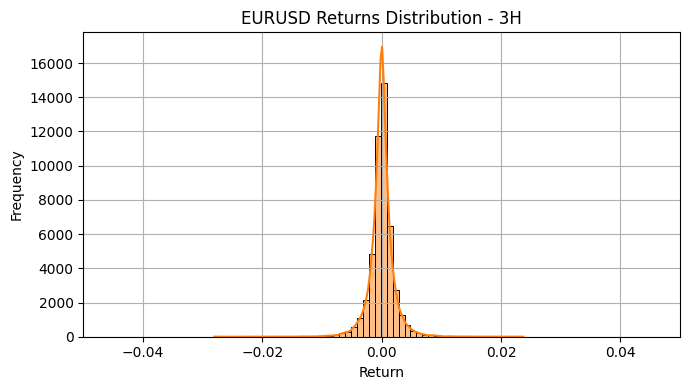

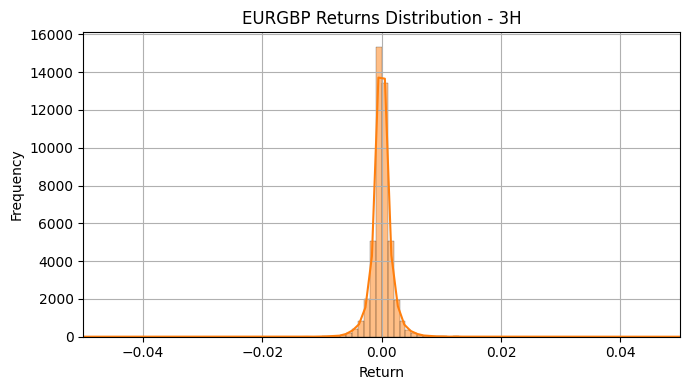

Plotting returns distribution for 6H interval


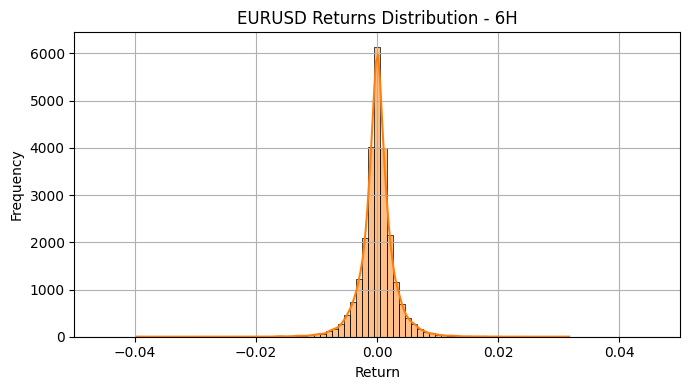

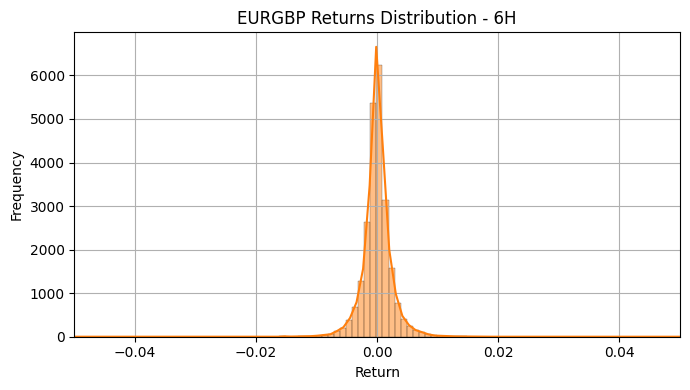

Plotting returns distribution for 1D interval


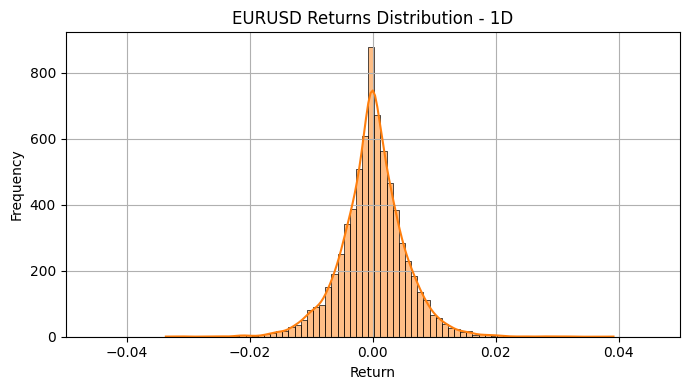

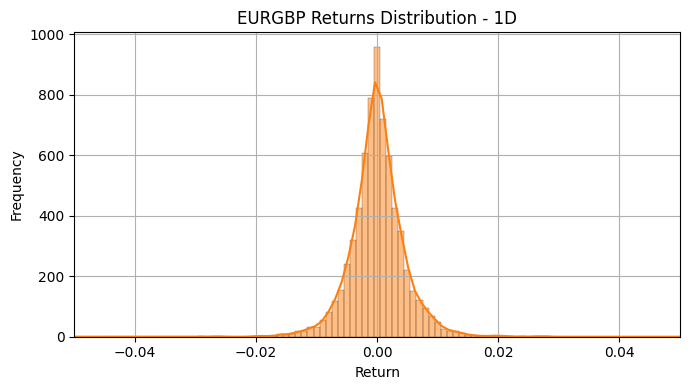

In [10]:
fx.plot_returns_distribution(fx_pairs[0:2], intervals, file_path)

In [7]:
eurusd_returns = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[0]}/", f"{fx_pairs[0]}_resampled_1T_returns.parquet"))
display(eurusd_returns.head())

,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2001-01-02 04:17:00,0.9470,0.9470,0.9470,0.9470,NaN,NaN,-0.000106
2001-01-02 04:18:00,0.9469,0.9469,0.9467,0.9469,-0.000106,-0.000106,-0.000106
2001-01-02 04:19:00,0.9471,0.9471,0.9468,0.9468,-0.000106,-0.000106,-0.000106
2001-01-02 04:20:00,0.9467,0.9467,0.9467,0.9467,-0.000106,-0.000106,0.000211
2001-01-02 04:21:00,0.9468,0.9469,0.9468,0.9469,0.000211,0.000211,0.000106


In [16]:
eurusd_returns_gap = {}
for interval in intervals:
    temp = fx.calc_returns_gap('EURUSD', interval, fx_pairs, file_path)
    eurusd_returns_gap[interval] = temp

Calculating returns gap for EURUSD at 1T interval
Calculating returns gap for EURUSD at 5T interval
Calculating returns gap for EURUSD at 10T interval
Calculating returns gap for EURUSD at 15T interval
Calculating returns gap for EURUSD at 30T interval
Calculating returns gap for EURUSD at 1H interval
Calculating returns gap for EURUSD at 3H interval
Calculating returns gap for EURUSD at 6H interval
Calculating returns gap for EURUSD at 1D interval


In [28]:
display(eurusd_returns_gap['15T'].head())

,ReturnGap_EURGBP_15T,ReturnGap_USDJPY_15T,ReturnGap_GBPUSD_15T,ReturnGap_USDCHF_15T,ReturnGap_USDCAD_15T,ReturnGap_AUDUSD_15T,ReturnGap_NZDUSD_15T,ReturnGap_EURJPY_15T,ReturnGap_GBPJPY_15T,ReturnGap_EURCHF_15T,ReturnGap_AUDJPY_15T,ReturnGap_EURAUD_15T,ReturnGap_GBPAUD_15T
DateTime,,,,,,,,,,,,,
2001-01-02 04:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-02 04:45:00,NaN,-0.001648,-0.000282,-0.001759,-0.000951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-02 05:00:00,NaN,-0.000901,-0.000285,0.000441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-02 05:15:00,NaN,0.000746,0.001665,-0.000522,-0.000211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-02 05:30:00,NaN,-0.001947,-0.000828,-0.002405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
interval = '15T'
print("Reference - EURUSD")
print("=" * 40)
for col in eurusd_returns_gap[interval].columns:
    fx.adf_test(pd.Series(eurusd_returns_gap[interval][col].dropna()))
    print("\n")
    fx.kpss_test(pd.Series(eurusd_returns_gap[interval][col].dropna()))
    print("\n\n")

Reference - EURUSD
ADF Statistics: -275.051233
p-value: 0.000000


KPSS Statistic: 0.21546115937258653
p-value: 0.1



ADF Statistics: -226.627495
p-value: 0.000000


KPSS Statistic: 0.2956283924920809
p-value: 0.1



ADF Statistics: -225.630772
p-value: 0.000000


KPSS Statistic: 0.06742709103725901
p-value: 0.1



ADF Statistics: -263.403613
p-value: 0.000000


KPSS Statistic: 0.1617594135035875
p-value: 0.1



ADF Statistics: -305.262087
p-value: 0.000000


KPSS Statistic: 0.2769086869218125
p-value: 0.1



ADF Statistics: -240.375925
p-value: 0.000000


KPSS Statistic: 0.0570068719517381
p-value: 0.1



ADF Statistics: -208.290978
p-value: 0.000000


KPSS Statistic: 0.05366441876743688
p-value: 0.1



ADF Statistics: -224.109360
p-value: 0.000000


KPSS Statistic: 0.3520280570397135
p-value: 0.09783273403460624



ADF Statistics: -231.945787
p-value: 0.000000


KPSS Statistic: 0.34608254054487664
p-value: 0.1



ADF Statistics: -420.157171
p-value: 0.000000


KPSS Statistic: 0.3493

In [29]:
eurusd_returns_gap_causation = fx.grangers_causation_matrix(eurusd_returns_gap['15T'])

Testing Granger Causality: Y = ReturnGap_EURGBP_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_USDJPY_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_GBPUSD_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_USDCHF_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_USDCAD_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_AUDUSD_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_NZDUSD_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_EURJPY_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_GBPJPY_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_EURCHF_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_AUDJPY_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_EURAUD_15T, X = ReturnGap_EURGBP_15T
Testing Granger Causality: Y = ReturnGap_GBPAUD_15T, X = ReturnG

In [30]:
display(eurusd_returns_gap_causation)

,ReturnGap_EURGBP_15T_x,ReturnGap_USDJPY_15T_x,ReturnGap_GBPUSD_15T_x,ReturnGap_USDCHF_15T_x,ReturnGap_USDCAD_15T_x,ReturnGap_AUDUSD_15T_x,ReturnGap_NZDUSD_15T_x,ReturnGap_EURJPY_15T_x,ReturnGap_GBPJPY_15T_x,ReturnGap_EURCHF_15T_x,ReturnGap_AUDJPY_15T_x,ReturnGap_EURAUD_15T_x,ReturnGap_GBPAUD_15T_x
ReturnGap_EURGBP_15T_y,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_USDJPY_15T_y,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_GBPUSD_15T_y,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_USDCHF_15T_y,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_USDCAD_15T_y,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_AUDUSD_15T_y,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_NZDUSD_15T_y,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_EURJPY_15T_y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
ReturnGap_GBPJPY_15T_y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
ReturnGap_EURCHF_15T_y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


These results suggest atleast a linear Granger-causal relationship between the various columns.

In [5]:
interval = '15T'
eurgbp_returns_15t = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[1]}/", f"{fx_pairs[1]}_resampled_{interval}_returns.parquet"))
eurusd_returns_15t = pd.read_parquet(os.path.join(file_path, f"{fx_pairs[0]}/", f"{fx_pairs[0]}_resampled_{interval}_returns.parquet"))

In [6]:
display(eurusd_returns_15t.head())
display(eurgbp_returns_15t.head())

,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2001-01-02 04:30:00,0.9470,0.9477,0.9463,0.9466,NaN,NaN,-0.000951
2001-01-02 04:45:00,0.9467,0.9467,0.9454,0.9457,-0.000951,-0.000951,0.000317
2001-01-02 05:00:00,0.9458,0.9466,0.9456,0.9460,0.000317,0.000317,-0.000211
2001-01-02 05:15:00,0.9459,0.9460,0.9456,0.9458,-0.000211,-0.000211,-0.001164
2001-01-02 05:30:00,0.9457,0.9457,0.9445,0.9447,-0.001163,-0.001164,0.000952


,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2002-03-03 19:15:00,0.6100,0.6101,0.6098,0.6099,NaN,NaN,0.000492
2002-03-03 19:30:00,0.6099,0.6103,0.6099,0.6102,0.000492,0.000492,-0.000328
2002-03-03 19:45:00,0.6102,0.6103,0.6098,0.6100,-0.000328,-0.000328,-0.000656
2002-03-03 20:00:00,0.6098,0.6100,0.6096,0.6096,-0.000656,-0.000656,0.000164
2002-03-03 20:15:00,0.6096,0.6098,0.6095,0.6097,0.000164,0.000164,0.000000


In [7]:
eurusd_returns_new, eurgbp_returns_new = fx.common_duration(eurusd_returns_15t, eurgbp_returns_15t)

In [8]:
display(eurusd_returns_new.index.min(), eurusd_returns_new.index.max())
# display(eurgbp_returns_new.head())

Timestamp('2002-03-03 19:30:00')

Timestamp('2023-12-29 16:45:00')

In [9]:
eurusd_train, eurusd_test = fx.get_train_test(eurusd_returns_new, '2010-12-31')
eurgbp_train, eurgbp_test = fx.get_train_test(eurgbp_returns_new, '2010-12-31')

In [37]:
#Null hypo: non-stationary
fx.adf_test(pd.Series(eurusd_train['Return']))
fx.adf_test(pd.Series(eurusd_train['logReturn']))
fx.adf_test(pd.Series(eurgbp_train['Return']))
fx.adf_test(pd.Series(eurgbp_train['logReturn']))

#Null hypo: stationary
fx.kpss_test(pd.Series(eurusd_train['Return']))
fx.kpss_test(pd.Series(eurusd_train['logReturn']))
fx.kpss_test(pd.Series(eurgbp_train['Return']))
fx.kpss_test(pd.Series(eurgbp_train['logReturn']))

ADF Statistics: -20.777644
p-value: 0.000000
ADF Statistics: -20.755968
p-value: 0.000000
ADF Statistics: -36.622889
p-value: 0.000000
ADF Statistics: -36.477047
p-value: 0.000000
KPSS Statistic: 0.7142483908411491
p-value: 0.012250146287168261
KPSS Statistic: 0.7100218367411897
p-value: 0.012634378478073664
KPSS Statistic: 0.17194622386514424
p-value: 0.1
KPSS Statistic: 0.1577852883772048
p-value: 0.1


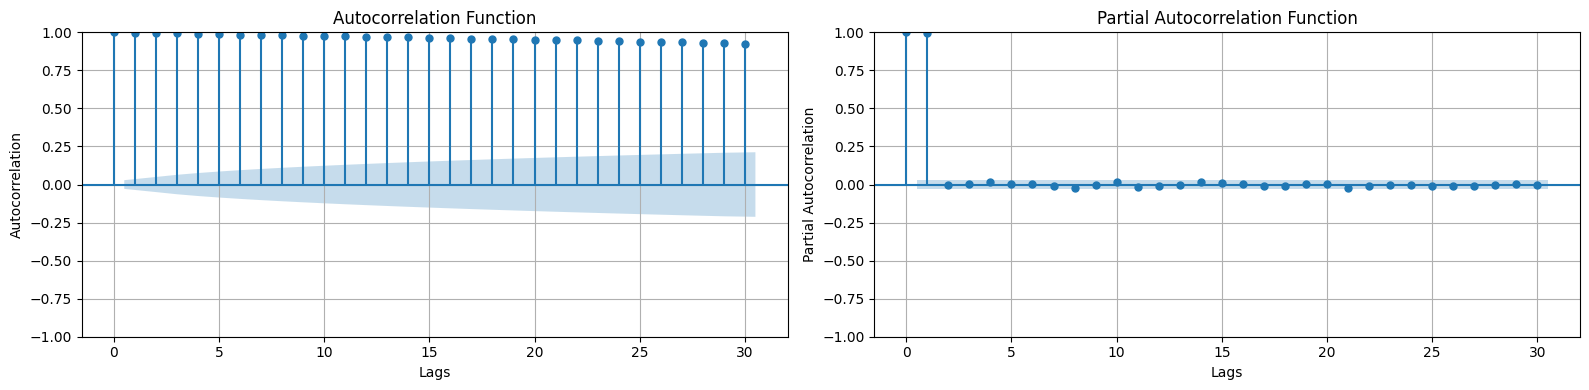

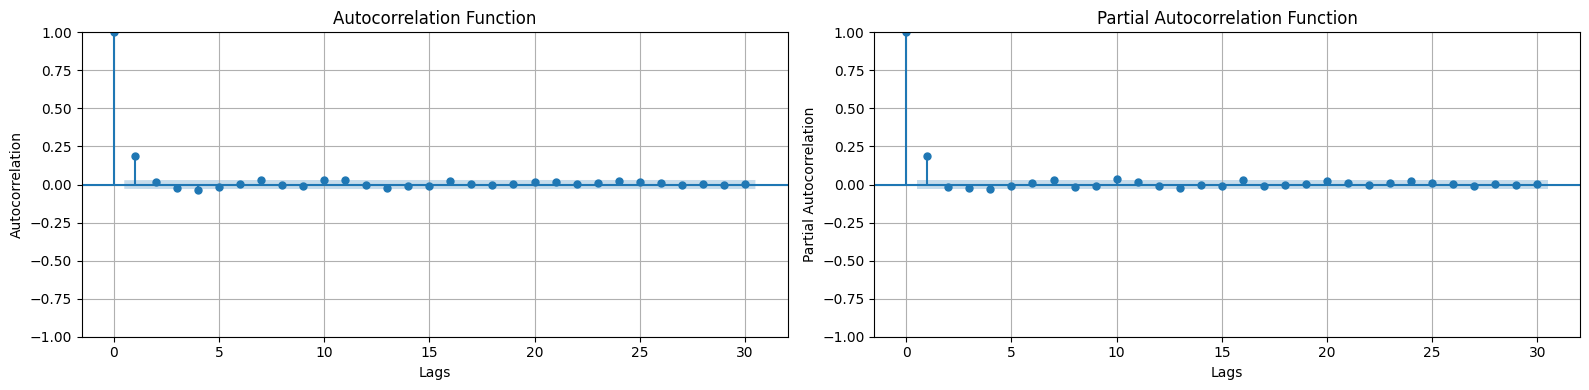

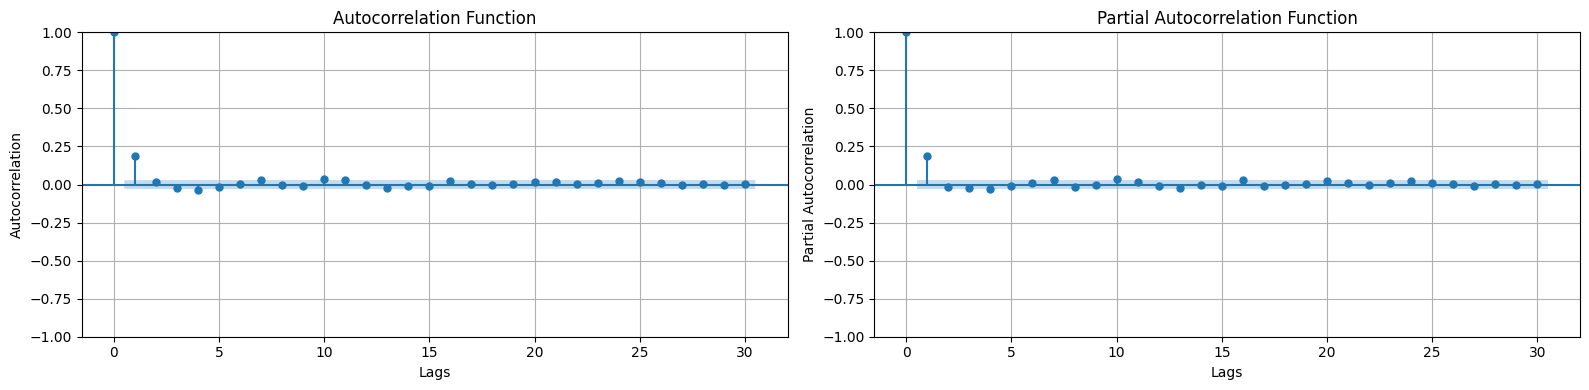

In [42]:
# fx.seasonal_decompose_and_plot(eurusd_returns_1d_train['Close'], period=252)
fx.acf_and_pacf(eurusd_train['Close'], lags=30)
fx.acf_and_pacf(eurusd_train['Return'], lags=30)
fx.acf_and_pacf(eurusd_train['logReturn'], lags=30)

Note: 
* For 'Close', the pacf spike at lag1 and sudden drop and slow trail-off of acf indicates non-stationarity.
* For 'Return' and 'logReturn', the acf and pacf spike at lag1 indicate an ARMA(1,1) process.

In [44]:
# Run Engle Granger
for field in ['Close', 'Return', 'logReturn']:
    score, pval, _ = coint(eurusd_train[field], eurgbp_train[field])
    print(f"Engle-Granger Cointegration Test:\nScore: {score}\nP-value: {pval}\n")
# If p-value < 0.05, we reject the null hypothesis of no cointegration, suggesting a long-term relationship between the two series.

Engle-Granger Cointegration Test:
Score: -2.7927187205910897
P-value: 0.16801242455276372

Engle-Granger Cointegration Test:
Score: -45.62068145660687
P-value: 0.0

Engle-Granger Cointegration Test:
Score: -45.58529197064887
P-value: 0.0



In [46]:
hedge_ratio = fx.get_beta_lr(eurusd_train['Return'], eurgbp_train['Return'])
spread = eurgbp_train['Return'] - hedge_ratio * eurusd_train['Return']
fx.adf_test(spread)

ADF Statistics: -36.510833
p-value: 0.000000


In [47]:
spread_lag = spread.shift(1)
spread_ret = spread - spread_lag
spread_lag = spread_lag[1:]
spread_ret = spread_ret[1:]

half_life = -np.log(2) / fx.get_beta_lr(spread_lag, spread_ret)
print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")

Estimated Half-Life of Mean Reversion: 0.77 periods


In [23]:
errors = {}
half_lives = {}
total_iterations = len(fx_pairs) * (len(fx_pairs) - 1) * len(intervals)

with tqdm(total=total_iterations, desc="Testing Mean Reversion") as pbar:
    for a in fx_pairs:
        for b in fx_pairs:
            if a != b:
                for interval in intervals:
                    temp1, temp2 = fx.test_half_life_mean_reversion(a, b, interval, file_path, 'Close', '2012-12-31')
                    if temp1 is not None and temp2 is not None:
                        errors[f"{a}_{b}_{interval}"] = (temp1, temp2)
                        half_lives[f"{a}_{b}_{interval}"] = 0
                    elif temp1 is not None and temp2 is None:
                        half_lives[f"{a}_{b}_{interval}"] = temp1
                    pbar.update(1)
                    pbar.set_postfix({"Current Pair": f"{a}_{b}", "Interval": interval})

Testing Mean Reversion:   0%|          | 0/1638 [00:00<?, ?it/s]

Loading data...
Aligning and preprocessing data...
Processing data...


Testing Mean Reversion:   0%|          | 1/1638 [00:24<11:09:29, 24.54s/it, Current Pair=EURUSD_EURGBP, Interval=1T]

Estimated Half-Life for EURUSD/EURGBP at interval 1T: 211017.36


Loading data...
Aligning and preprocessing data...


Testing Mean Reversion:   0%|          | 2/1638 [00:32<6:39:54, 14.67s/it, Current Pair=EURUSD_EURGBP, Interval=5T] 

...

Aligning and preprocessing data...
Processing data...
Estimated Half-Life for GBPAUD/EURAUD at interval 30T: 5072.50


Loading data...


Testing Mean Reversion: 100%|█████████▉| 1637/1638 [1:33:18<00:00,  1.04it/s, Current Pair=GBPAUD_EURAUD, Interval=6H] 

Aligning and preprocessing data...
Processing data...
Estimated Half-Life for GBPAUD/EURAUD at interval 1H: 2660.14


Loading data...
Aligning and preprocessing data...
Processing data...
Estimated Half-Life for GBPAUD/EURAUD at interval 3H: 889.85


Loading data...
Aligning and preprocessing data...
Processing data...
Estimated Half-Life for GBPAUD/EURAUD at interval 6H: 474.11


Loading data...


Testing Mean Reversion: 100%|██████████| 1638/1638 [1:33:18<00:00,  3.42s/it, Current Pair=GBPAUD_EURAUD, Interval=1D]


Aligning and preprocessing data...
Processing data...
Estimated Half-Life for GBPAUD/EURAUD at interval 1D: 121.48




In [24]:
with open('./temp/half_lives.pkl', 'wb') as f:
    pickle.dump(half_lives, f)


In [16]:
print(len(list(half_lives.keys())))
half_lives_new = {k: v for k, v in half_lives.items() if v > 10 and v < 100}
print(len(list(half_lives_new.keys())))

1638
106


In [17]:
pairs_set = set()
for key in half_lives_new.keys():
    parts = key.split('_')
    if len(parts) >= 3:
        pair1 = parts[0]
        pair2 = parts[1]
        pairs_set.add(pair1)
        pairs_set.add(pair2)

pairs = sorted(pairs_set)
half_lives_df = pd.DataFrame(index=pairs, columns=pairs, dtype=object)

for pair1 in pairs:
    for pair2 in pairs:
        values = []
        for interval in intervals:
            key = f"{pair1}_{pair2}_{interval}"
            values.append(float(half_lives_new.get(key, 0)))
        half_lives_df.loc[pair1, pair2] = values

In [18]:
display(half_lives_df)

,AUDJPY,AUDUSD,EURAUD,EURCHF,EURGBP,EURJPY,EURUSD,GBPAUD,GBPJPY,GBPUSD,NZDUSD,USDCAD,USDCHF,USDJPY
AUDJPY,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 90.93095925961975, 45.44465747572718, 30...","[43.50831439579787, 42.2156533362514, 22.35467...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[17.35452614916874, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
AUDUSD,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 90.94438134347465, 45.47105224172561, 30...","[43.122110482426244, 41.352687441515705, 21.90...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[18.30775803325381, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
EURAUD,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 87.32324863484075, 44.93233157246498, 30...","[42.08016508698284, 42.20193395727607, 22.6511...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[19.94884417474955, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
EURCHF,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[13.54956228777676, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
EURGBP,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[15.376887842271692, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
EURJPY,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 90.84978625617806, 45.55924529885806, 30...","[43.123206570214464, 41.20364462641875, 22.128...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[13.634817007277702, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0,

In [19]:
baseline_hedge_ratios = pd.DataFrame(0, index=half_lives_df.index, columns=half_lives_df.columns, dtype=object)
baseline_half_lives = pd.DataFrame(0, index=half_lives_df.index, columns=half_lives_df.columns, dtype=object)
baseline_hedge_data = {}
for pair1 in pairs:
    for pair2 in pairs:
        half_lives_df_values = half_lives_df.loc[pair1, pair2]
        hr_list = []
        hl_list = []
        for interval in intervals:
            interval_idx = intervals.index(interval)
            if half_lives_df_values[interval_idx] != 0:
                baseline_hr, baseline_hl = fx.get_baseline_hedge_ratio_and_half_life(pair1, pair2, interval, file_path, 'Close', '2010-12-31')
                hr_list.append(baseline_hr)
                hl_list.append(baseline_hl)
            else:
                print("Skipping...")
                hr_list.append(0)
                hl_list.append(0)
        if hr_list and hl_list:
            baseline_hedge_ratios.loc[pair1, pair2] = hr_list
            baseline_half_lives.loc[pair1, pair2] = hl_list
with open('./temp/baseline_hedge_ratios.pkl', 'wb') as f:
    pickle.dump(baseline_hedge_ratios, f)
with open('./temp/baseline_half_lives.pkl', 'wb') as f:
    pickle.dump(baseline_half_lives, f)

Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Skipping...
Skipping...
Skipping...
Skipping...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Loading data...
Aligning and preprocessing data...
Processing data...
Skipping...
Skipping...
Skipping...
Skipping...
Skipping

In [20]:
for row in baseline_half_lives.index:
    for col in baseline_half_lives.columns:
        values_l = baseline_half_lives.loc[row, col]
        values_l = [np.round(v, 2) for v in values_l]
        baseline_half_lives.loc[row, col] = values_l
display(baseline_half_lives)

,AUDJPY,AUDUSD,EURAUD,EURCHF,EURGBP,EURJPY,EURUSD,GBPAUD,GBPJPY,GBPUSD,NZDUSD,USDCAD,USDCHF,USDJPY
AUDJPY,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 30.0, 30.59, 27.91, 27.75, 0, 0, 0, 0]","[361.73, 355.63, 363.22, 331.57, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[399507.54, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
AUDUSD,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 12665.1, 6374.43, 4263.16, 2142.57, 0, 0, ...","[151509.17, 107407.44, 55516.65, 37588.28, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[272889.08, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
EURAUD,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 10168.32, 5107.91, 3415.47, 1714.63, 0, 0,...","[251598.78, 171386.85, 89984.36, 61092.69, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[115309.04, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
EURCHF,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[70000.6, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
EURGBP,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[460742.8, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
EURJPY,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 1931.02, 1226.9, 822.05, 414.19, 0, 0, 0, 0]","[221291.71, 110692.11, 68140.31, 46144.04, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[142404.68, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
EURUSD,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[28448.09, 8474.63, 4297.14, 29912.32, 16648.2...","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 11253.55, 5659.0, 3784.32, 1899.67, 0, 0, ...","[188755.4, 153463.71, 80391.61, 54506.57, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[291466.54, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
GBPAUD,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]"
GBPJPY,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 4136.19, 2085.81, 1396.93, 703.21, 0, 0, 0...","[95775.07, 56519.09, 29461.13, 19863.83, 0, 0,..."

* Initial Test period for static hedge ratios and half-lives: 2011-01-01 to 2015-12-31

In [ ]:
for pair1 in fx_pairs:
    for pair2 in fx_pairs:
        if pair1 != pair2:
            for interval in intervals:
                print("Loading...")
                pair1_df = tf.load_resampled_returns(pair1, interval, file_path)
                pair2_df = tf.load_resampled_returns(pair2, interval, file_path)
                print("Extracting training data...")
                pair1_train, pair1_test = fx.get_train_test(pair1_df, '2010-12-31')
                pair2_train, pair2_test = fx.get_train_test(pair2_df, '2010-12-31')
                print("Aligning data...")
                pair1_train, pair2_train = fx.common_duration(pair1_train, pair2_train, 252)
                print("Running cointegration test...")
                score, pval, _ = coint(pair1_train['Close'], pair2_train['Close'])
                print(f"{interval} - {pair1} & {pair2} - Engle-Granger Cointegration p-value: {pval}")
                if pval < 0.05:
                    print(f"COINTEGRATED")
                else:
                    pass

Loading...
Extracting training data...
Aligning data...
Running cointegration test...


In [24]:
print(eurusd_train.head())

                       Open    High     Low   Close    Return  logReturn
2002-03-03 19:30:00  0.8656  0.8662  0.8655  0.8662  0.000693   0.000693
2002-03-03 19:45:00  0.8661  0.8663  0.8656  0.8656 -0.000693  -0.000693
2002-03-03 20:00:00  0.8655  0.8657  0.8651  0.8653 -0.000347  -0.000347
2002-03-03 20:15:00  0.8654  0.8657  0.8652  0.8656  0.000347   0.000347
2002-03-03 20:30:00  0.8657  0.8658  0.8656  0.8657  0.000116   0.000116


ADF p-value: 0.6723
Estimated Half-Life of Mean Reversion: 54506.57 periods
Hedge Ratio: 0.3541


NameError: name 'spread_ret' is not defined

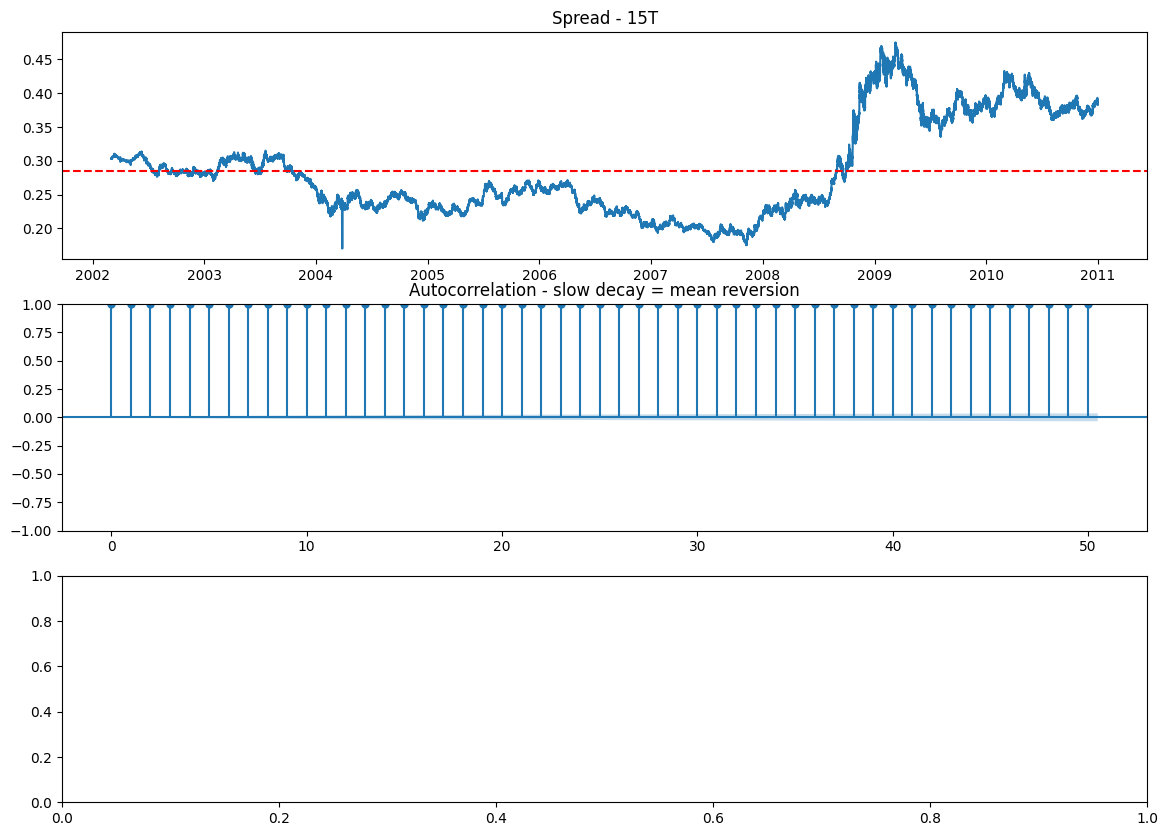

In [ ]:
# 1. Visual check - do spreads mean revert?
pair1 = eurusd_train
pair2 = eurgbp_train
def plot_spread_diagnostic(pair1, pair2, interval):

    hedge_ratio = fx.get_beta_lr(pair1['Close'], pair2['Close'])
    spread = pair2['Close'] - hedge_ratio * pair1['Close']

    # 3. The SPREAD should be stationary I(0)
    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(spread.dropna(), maxlag=50)
    print(f"ADF p-value: {adf_result[1]:.4f}")
    # If p < 0.05, spread is stationary → cointegrated

    # 4. Calculate half-life on the STATIONARY spread
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread - spread_lag
    spread_ret = spread_diff.dropna()
    beta = fx.get_beta_lr(spread_lag.dropna(), spread_ret.dropna())
    half_life = -np.log(2) / beta
    print(f"Estimated Half-Life of Mean Reversion: {half_life:.2f} periods")
    print(f"Hedge Ratio: {hedge_ratio:.4f}")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Raw spread
    axes[0].plot(spread.index, spread)
    axes[0].set_title(f'Spread - {interval}')
    axes[0].axhline(spread.mean(), color='red', linestyle='--')
    
    # ACF plot - should decay slowly if mean reverting
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(spread.dropna(), lags=50, ax=axes[1])
    axes[1].set_title('Autocorrelation - slow decay = mean reversion')
    
    # Regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(spread_lag.values.reshape(-1,1), spread_ret.values)
    beta = model.coef_[0]
    
    axes[2].scatter(spread_lag, spread_ret, alpha=0.1, s=1)
    axes[2].plot(spread_lag, model.predict(spread_lag.values.reshape(-1,1)), 
                 'r-', label=f'beta={beta:.6f}')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[2].set_xlabel('Spread(t-1)')
    axes[2].set_ylabel('Spread(t) - Spread(t-1)')
    axes[2].set_title('Mean Reversion Check - negative slope = reversion')
    axes[2].legend()
    
    plt.tight_layout()
    
    if beta >= 0:
        print(f"BETA POSITIVE ({beta:.6f}) - NO MEAN REVERSION")
    else:
        half_life = -np.log(2) / beta
        print(f"Beta: {beta:.6f}, Half-life: {half_life:.2f} bars")
    
    return beta, half_life if beta < 0 else np.inf


beta, half_life = plot_spread_diagnostic(pair1, 
                                    pair2, 
                                    interval)
plt.show()

In [87]:
pair1 = 'EURUSD'
pair2 = 'EURGBP'
interval = '15T'
idx = intervals.index(interval)
hedge_ratio_baseline = baseline_hedge_ratios.loc[pair1, pair2][idx]
half_life_baseline = baseline_half_lives.loc[pair1, pair2][idx]
signals, returns, trades, fig = tf.backtest_pairs_main(pair1, pair2, interval, hedge_ratio_baseline=hedge_ratio_baseline, half_life_baseline=half_life_baseline, start='2011-01-01', end='2015-12-31', file_path=file_path)

NameError: name 'print_performance' is not defined

In [85]:
display(signals.describe())

,spread,z_score,signal,position
count,1.751050e+05,128726.000000,175105.000000,175105.000000
mean,-4.714701e-07,0.000089,-0.000874,-0.000868
std,3.516413e-04,1.002342,0.305821,0.305812
min,-9.620445e-03,-3.880570,-1.000000,-1.000000
25%,-8.989172e-05,-0.575822,0.000000,0.000000
50%,0.000000e+00,-0.001819,0.000000,0.000000
75%,8.856407e-05,0.574345,0.000000,0.000000
max,1.004978e-02,3.880570,1.000000,1.000000


In [ ]:
# For each pair which has a valid hedge ratio and half-life, run backtest and save results as a pickle file for later analysis and visualization. Note that since we are using static hedge ratio, we will also use static window size for rolling calculations in signal generation to avoid future data leakage.
valid_pairs = []
backtest_results = {}
for pair1 in baseline_half_lives.index:
    for pair2 in baseline_half_lives.columns:
        half_lives = baseline_half_lives.loc[pair1, pair2]
        for idx, half_life_baseline in enumerate(half_lives):
            if half_life_baseline != 0:
                interval = intervals[idx]
                # key = f"{pair1}_{pair2}_{interval}"
                valid_pairs.append((pair1, pair2, interval))
                print(f"Backtesting {pair1} and {pair2} at {interval} interval with half-life {half_life_baseline}...")
                hedge_ratio_baseline = baseline_hedge_ratios.loc[pair1, pair2][idx]
                # pair1_train, pair1_test = fx.get_train_test(fx.load_resampled_returns(pair1, interval, file_path), '2015-01-01')
                # pair2_train, pair2_test = fx.get_train_test(fx.load_resampled_returns(pair2, interval, file_path), '2015-01-01')
                backtest_res = tf.backtest_pairs_main(pair1, pair2, interval, hedge_ratio_baseline, half_life_baseline, start='2011-01-01', end='2015-12-31', file_path=file_path)
                backtest_results[f"{pair1}_{pair2}_{interval}"] = backtest_res
            else:
                print(f"Skipping {pair1} and {pair2} at {interval} interval due to invalid half-life...")
        


,AUDJPY,AUDUSD,EURAUD,EURCHF,EURGBP,EURJPY,EURUSD,GBPAUD,GBPJPY,GBPUSD,NZDUSD,USDCAD,USDCHF,USDJPY
AUDJPY,0.0,0.000000,0.0,0.000002,7.597952e-07,0.0,0.0,-0.298501,0.0,0.0,0.0,0.0,0.0,0.0
AUDUSD,0.0,0.000000,0.0,0.056400,4.859524e-02,0.0,0.0,-0.633270,0.0,0.0,0.0,0.0,0.0,0.0
EURAUD,0.0,0.000000,0.0,-0.102611,1.074867e-01,0.0,0.0,0.665159,0.0,0.0,0.0,0.0,0.0,0.0
EURCHF,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.0,-0.091194,0.0,0.0,0.0,0.0,0.0,0.0
EURGBP,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.0,-0.613659,0.0,0.0,0.0,0.0,0.0,0.0
EURJPY,0.0,0.000000,0.0,0.086003,9.158432e-02,0.0,0.0,-0.045191,0.0,0.0,0.0,0.0,0.0,0.0
EURUSD,0.0,0.620285,0.0,0.025492,2.924743e-01,0.0,0.0,-0.246146,0.0,0.0,0.0,0.0,0.0,0.0
GBPAUD,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
GBPJPY,0.0,0.000000,0.0,0.105594,-2.188193e-01,0.0,0.0,0.207863,0.0,0.0,0.0,0.0,0.0,0.0
GBPUSD,0.0,-0.211724,0.0,0.034118,-3.093420e-01,0.0,0.0,0.491141,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
eurusd_train, eurusd_test = fx.get_train_test(tf.load_resampled_returns('EURUSD', '30T', file_path), '2015-01-01')
eurgbp_train, eurgbp_test = fx.get_train_test(tf.load_resampled_returns('EURGBP', '15T', file_path), '2015-01-01')

In [74]:
eurusd_train2, eurgbp_train2 = fx.common_duration(eurusd_train, eurgbp_train)

df1: 30T, df2: 15T. Downsampling to common frequency.


In [75]:
display(eurusd_train.head())
display(eurgbp_train.head())

,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2001-01-02 04:30:00,0.9470,0.9477,0.9463,0.9466,NaN,NaN,-0.000634
2001-01-02 05:00:00,0.9467,0.9467,0.9454,0.9460,-0.000634,-0.000634,-0.001375
2001-01-02 05:30:00,0.9459,0.9460,0.9445,0.9447,-0.001374,-0.001375,0.001269
2001-01-02 06:00:00,0.9449,0.9460,0.9448,0.9459,0.001270,0.001269,0.000317
2001-01-02 06:30:00,0.9458,0.9463,0.9453,0.9462,0.000317,0.000317,-0.001163


,Open,High,Low,Close,Return,logReturn,target
DateTime,,,,,,,
2002-03-03 19:15:00,0.6100,0.6101,0.6098,0.6099,NaN,NaN,0.000492
2002-03-03 19:30:00,0.6099,0.6103,0.6099,0.6102,0.000492,0.000492,-0.000328
2002-03-03 19:45:00,0.6102,0.6103,0.6098,0.6100,-0.000328,-0.000328,-0.000656
2002-03-03 20:00:00,0.6098,0.6100,0.6096,0.6096,-0.000656,-0.000656,0.000164
2002-03-03 20:15:00,0.6096,0.6098,0.6095,0.6097,0.000164,0.000164,0.000000


In [76]:
display(eurusd_train2.head(10))
display(eurgbp_train2.head(10))

,Open,High,Low,Close,Return,logReturn
2002-03-03 19:30:00,0.8653,0.8662,0.8653,0.8662,0.002430,0.002427
2002-03-03 20:00:00,0.8661,0.8663,0.8651,0.8653,-0.001039,-0.001040
2002-03-03 20:30:00,0.8654,0.8658,0.8652,0.8657,0.000462,0.000462
2002-03-03 21:00:00,0.8657,0.8660,0.8654,0.8659,0.000231,0.000231
2002-03-03 21:30:00,0.8658,0.8659,0.8658,0.8658,-0.000115,-0.000115
2002-03-03 22:00:00,0.8659,0.8666,0.8658,0.8662,0.000462,0.000462
2002-03-03 22:30:00,0.8663,0.8666,0.8662,0.8663,0.000115,0.000115
2002-03-03 23:00:00,0.8663,0.8665,0.8663,0.8664,0.000115,0.000115
2002-03-03 23:30:00,0.8662,0.8664,0.8653,0.8656,-0.000923,-0.000924
2002-03-04 00:00:00,0.8658,0.8658,0.8655,0.8657,0.000116,0.000116


,Open,High,Low,Close,Return,logReturn
2002-03-03 19:30:00,0.6099,0.6103,0.6099,0.6102,0.000000,0.000000
2002-03-03 20:00:00,0.6102,0.6103,0.6096,0.6096,-0.000983,-0.000984
2002-03-03 20:30:00,0.6096,0.6098,0.6095,0.6097,0.000164,0.000164
2002-03-03 21:00:00,0.6097,0.6100,0.6097,0.6099,0.000328,0.000328
2002-03-03 21:30:00,0.6099,0.6101,0.6099,0.6101,0.000328,0.000328
2002-03-03 22:00:00,0.6101,0.6106,0.6100,0.6102,0.000164,0.000164
2002-03-03 22:30:00,0.6103,0.6105,0.6102,0.6102,0.000000,0.000000
2002-03-03 23:00:00,0.6102,0.6102,0.6101,0.6102,0.000000,0.000000
2002-03-03 23:30:00,0.6102,0.6102,0.6096,0.6098,-0.000656,-0.000656
2002-03-04 00:00:00,0.6098,0.6098,0.6096,0.6097,-0.000164,-0.000164


In [119]:
df_audusd_5m['o/h'] = df_audusd_5m['<OPEN>'] / df_audusd_5m['<HIGH>']
df_audusd_5m['o/l'] = df_audusd_5m['<OPEN>'] / df_audusd_5m['<LOW>']
df_audusd_5m['o/c'] = df_audusd_5m['<OPEN>'] / df_audusd_5m['<CLOSE>']
df_audusd_5m['h/l'] = df_audusd_5m['<HIGH>'] / df_audusd_5m['<LOW>']
df_audusd_5m['h/c'] = df_audusd_5m['<HIGH>'] / df_audusd_5m['<CLOSE>']
df_audusd_5m['l/c'] = df_audusd_5m['<LOW>'] / df_audusd_5m['<CLOSE>']

df_audusd_5m.head(5)


,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,o/l,o/c,h/l,h/c,l/c
2010-01-03 23:05:00,0.8992,0.8995,0.8988,0.8990,1.0,NaN,NaN,NaN,NaN,0.999666,1.000445,1.000222,1.000779,1.000556,0.999778
2010-01-03 23:10:00,0.8990,0.8992,0.8986,0.8992,1.0,0.000222,NaN,NaN,NaN,0.999778,1.000445,0.999778,1.000668,1.000000,0.999333
2010-01-03 23:15:00,0.8991,0.8994,0.8990,0.8991,1.0,-0.000111,0.000111,NaN,NaN,0.999666,1.000111,1.000000,1.000445,1.000334,0.999889
2010-01-03 23:20:00,0.8991,0.8993,0.8991,0.8992,1.0,0.000111,0.000000,0.000222,NaN,0.999778,1.000000,0.999889,1.000222,1.000111,0.999889
2010-01-03 23:25:00,0.8991,0.8991,0.8988,0.8988,1.0,-0.000445,-0.000334,-0.000445,-0.000222,1.000000,1.000334,1.000334,1.000334,1.000334,1.000000


In [126]:
#Calculate 5 quantile levels for each of these new feature columns
quantiles = [0.2, 0.4, 0.6, 0.8, 1.0]

for col in ['o/h', 'o/l', 'o/c', 'h/l', 'h/c', 'l/c']:
    # compute thresholds
    q_vals = df_audusd_5m[col].quantile(quantiles)
    q20, q40, q60, q80, q100 = [q_vals[q] for q in quantiles]

    # define exclusive masks
    masks = [
        df_audusd_5m[col] <= q20,                                 # <= 0.2
        (df_audusd_5m[col] > q20) & (df_audusd_5m[col] <= q40),   # (0.2, 0.4]
        (df_audusd_5m[col] > q40) & (df_audusd_5m[col] <= q60),   # (0.4, 0.6]
        (df_audusd_5m[col] > q60) & (df_audusd_5m[col] <= q80),   # (0.6, 0.8]
        (df_audusd_5m[col] > q80) & (df_audusd_5m[col] <= q100),  # (0.8, 1.0]
    ]

    names = [f"{col}_q{int(q*100)}" for q in quantiles]  # q20, q40, q60, q80, q100

    for name, mask in zip(names, masks):
        df_audusd_5m[name] = mask.astype(int)
        print(f"Calculated exclusive quantile column: {name} with thresholds {q20:.6e}, {q40:.6e}, {q60:.6e}, {q80:.6e}, {q100:.6e}")


Calculated exclusive quantile column: o/h_q20 with thresholds 9.993851e-01, 9.997932e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q40 with thresholds 9.993851e-01, 9.997932e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q60 with thresholds 9.993851e-01, 9.997932e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q80 with thresholds 9.993851e-01, 9.997932e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q100 with thresholds 9.993851e-01, 9.997932e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/l_q20 with thresholds 1.000000e+00, 1.000000e+00, 1.000201e+00, 1.000562e+00, 1.044965e+00
Calculated exclusive quantile column: o/l_q40 with thresholds 1.000000e+00, 1.000000e+00, 1.000201e+00, 1.000562e+00, 1.044965e+00
Calculated exclusive quantile column: o/l_q60 with thresholds 1.000000e+00, 1.0000

In [127]:
df_audusd_5m.head(10)

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,l/c_q20,l/c_q40,l/c_q60,l/c_q80,o/h_q100,o/l_q100,o/c_q100,h/l_q100,h/c_q100,l/c_q100
2010-01-03 23:05:00,0.8992,0.8995,0.8988,0.8990,1.0,NaN,NaN,NaN,NaN,0.999666,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:10:00,0.8990,0.8992,0.8986,0.8992,1.0,0.000222,NaN,NaN,NaN,0.999778,...,1,0,0,0,0,0,0,0,0,0
2010-01-03 23:15:00,0.8991,0.8994,0.8990,0.8991,1.0,-0.000111,0.000111,NaN,NaN,0.999666,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:20:00,0.8991,0.8993,0.8991,0.8992,1.0,0.000111,0.000000,0.000222,NaN,0.999778,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:25:00,0.8991,0.8991,0.8988,0.8988,1.0,-0.000445,-0.000334,-0.000445,-0.000222,1.000000,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:30:00,0.8989,0.8989,0.8988,0.8989,1.0,0.000111,-0.000334,-0.000222,-0.000334,1.000000,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:35:00,0.8989,0.8989,0.8981,0.8986,1.0,-0.000334,-0.000223,-0.000667,-0.000556,1.000000,...,0,1,0,0,0,1,0,0,0,0
2010-01-03 23:40:00,0.8985,0.8990,0.8985,0.8989,1.0,0.000334,0.000000,0.000111,-0.000334,0.999444,...,0,1,0,0,0,0,0,0,0,0
2010-01-03 23:45:00,0.8989,0.8989,0.8986,0.8986,1.0,-0.000334,0.000000,-0.000334,-0.000223,1.000000,...,0,0,1,0,0,0,0,0,0,0
2010-01-03 23:50:00,0.8984,0.8985,0.8978,0.8980,1.0,-0.000668,-0.001002,-0.000668,-0.001002,0.999889,...,0,0,1,0,0,1,1,0,0,0


In [131]:
#resample to 15mins
df_audusd_15m = df_audusd_ffill.resample('15T', label='right').agg({
    '<OPEN>': 'first',
    '<HIGH>': 'max',
    '<LOW>': 'min',
    '<CLOSE>': 'last',
    'flag': 'max',
})

df_audusd_15m.head(5)
print(df_audusd_15m['flag'].value_counts())

#Calculate close-to-close log returns for 4 periods for 15min data
for period in [1, 2, 3, 4]:
    df_audusd_15m[f'ret_{period}'] = (np.log(df_audusd_15m['<CLOSE>'] / df_audusd_15m['<CLOSE>'].shift(periods=period))).shift(-period)

#drop rows with time index in 00:00:15 to 03:00:00
drop_idx_15m = df_audusd_15m.between_time('00:00:15', '03:00:00').index
df_audusd_15m = df_audusd_15m.drop(index=drop_idx_15m)
df_audusd_15m.head(20)

df_audusd_15m['o/h'] = df_audusd_15m['<OPEN>'] / df_audusd_15m['<HIGH>']
df_audusd_15m['o/l'] = df_audusd_15m['<OPEN>'] / df_audusd_15m['<LOW>']
df_audusd_15m['o/c'] = df_audusd_15m['<OPEN>'] / df_audusd_15m['<CLOSE>']
df_audusd_15m['h/l'] = df_audusd_15m['<HIGH>'] / df_audusd_15m['<LOW>']
df_audusd_15m['h/c'] = df_audusd_15m['<HIGH>'] / df_audusd_15m['<CLOSE>']
df_audusd_15m['l/c'] = df_audusd_15m['<LOW>'] / df_audusd_15m['<CLOSE>']

df_audusd_15m.head(5)

#Calculate 5 quantile bins for each of these new feature columns
quantiles = [0.2, 0.4, 0.6, 0.8, 1.0]

for col in ['o/h', 'o/l', 'o/c', 'h/l', 'h/c', 'l/c']:
    # compute thresholds
    q_vals = df_audusd_15m[col].quantile(quantiles)
    q20, q40, q60, q80, q100 = [q_vals[q] for q in quantiles]

    # define exclusive masks
    masks = [
        df_audusd_15m[col] <= q20,                                 # <= 0.2
        (df_audusd_15m[col] > q20) & (df_audusd_15m[col] <= q40),   # (0.2, 0.4]
        (df_audusd_15m[col] > q40) & (df_audusd_15m[col] <= q60),   # (0.4, 0.6]
        (df_audusd_15m[col] > q60) & (df_audusd_15m[col] <= q80),   # (0.6, 0.8]
        (df_audusd_15m[col] > q80) & (df_audusd_15m[col] <= q100),  # (0.8, 1.0]
    ]

    names = [f"{col}_q{int(q*100)}" for q in quantiles]  # q20, q40, q60, q80, q100

    for name, mask in zip(names, masks):
        df_audusd_15m[name] = mask.astype(int)
        print(f"Calculated exclusive quantile column: {name} with thresholds {q20:.6e}, {q40:.6e}, {q60:.6e}, {q80:.6e}, {q100:.6e}")


/var/folders/sr/p42wz5n11rzcm2dvgg2x75l00000gn/T/ipykernel_978/2549909630.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_audusd_15m = df_audusd_ffill.resample('15T', label='right').agg({


flag
1.0    22429
0.0     8346
Name: count, dtype: int64
Calculated exclusive quantile column: o/h_q20 with thresholds 9.981470e-01, 9.994795e-01, 9.998925e-01, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q40 with thresholds 9.981470e-01, 9.994795e-01, 9.998925e-01, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q60 with thresholds 9.981470e-01, 9.994795e-01, 9.998925e-01, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q80 with thresholds 9.981470e-01, 9.994795e-01, 9.998925e-01, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/h_q100 with thresholds 9.981470e-01, 9.994795e-01, 9.998925e-01, 1.000000e+00, 1.000000e+00
Calculated exclusive quantile column: o/l_q20 with thresholds 1.000000e+00, 1.000106e+00, 1.000533e+00, 1.001972e+00, 1.043489e+00
Calculated exclusive quantile column: o/l_q40 with thresholds 1.000000e+00, 1.000106e+00, 1.000533e+00, 1.001972e+00, 1.043489e+00
Calculated exclusive quan

In [132]:
df_audusd_15m.describe()

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,h/c_q20,h/c_q40,h/c_q60,h/c_q80,h/c_q100,l/c_q20,l/c_q40,l/c_q60,l/c_q80,l/c_q100
count,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30049.000000,29686.000000,29323.000000,30412.000000,...,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.0
mean,0.919761,0.921068,0.918441,0.919850,0.729054,0.000003,0.000006,0.000009,0.000013,0.998573,...,0.337564,0.062442,0.200085,0.199888,0.200020,0.200020,0.199987,0.199987,0.400007,0.0
std,0.048169,0.048024,0.048339,0.048192,0.444455,0.000914,0.001282,0.001552,0.001784,0.002959,...,0.472887,0.241961,0.400071,0.399923,0.400021,0.400021,0.399997,0.399997,0.489907,0.0
min,0.806900,0.810300,0.806500,0.807000,0.000000,-0.023909,-0.025370,-0.026588,-0.031354,0.960928,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.889400,0.889600,0.888600,0.889400,0.000000,-0.000224,-0.000335,-0.000433,-0.000498,0.998699,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.914300,0.915100,0.913500,0.914400,1.000000,0.000000,0.000000,0.000000,0.000000,0.999773,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,0.965700,0.967100,0.963300,0.965300,1.000000,0.000232,0.000398,0.000495,0.000572,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0
max,1.023300,1.025300,1.023200,1.023400,1.000000,0.027014,0.027257,0.027139,0.026547,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [174]:
df_audusd_15m

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,l/c_q20,l/c_q40,l/c_q60,l/c_q80,l/c_q100,ret_1_q20,ret_1_q40,ret_1_q60,ret_1_q80,ret_1_q100
2010-01-03 23:15:00,0.8992,0.8995,0.8986,0.8991,1.0,-0.000222,-0.000556,-0.002227,-0.002227,0.999666,...,0,0,1,0,0,0,1,0,0,0
2010-01-03 23:30:00,0.8991,0.8993,0.8988,0.8989,1.0,-0.000334,-0.002004,-0.002004,NaN,0.999778,...,0,0,0,1,0,0,1,0,0,0
2010-01-03 23:45:00,0.8989,0.8990,0.8981,0.8986,1.0,-0.001671,-0.001671,NaN,NaN,0.999889,...,0,0,1,0,0,1,0,0,0,0
2010-01-04 00:00:00,0.8984,0.8985,0.8971,0.8971,1.0,0.000000,NaN,NaN,NaN,0.999889,...,0,0,0,1,0,0,1,0,0,0
2010-01-04 03:15:00,0.8960,0.8974,0.8957,0.8958,1.0,-0.000893,-0.000782,0.000112,0.000670,0.998440,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-31 23:00:00,1.0172,1.0172,1.0171,1.0171,1.0,-0.000295,-0.000295,-0.000295,-0.000393,1.000000,...,0,0,0,1,0,0,1,0,0,0
2010-12-31 23:15:00,1.0156,1.0169,1.0156,1.0168,1.0,0.000000,0.000000,-0.000098,-0.000098,0.998722,...,0,1,0,0,0,0,1,0,0,0
2010-12-31 23:30:00,1.0168,1.0168,1.0168,1.0168,1.0,0.000000,-0.000098,-0.000098,NaN,1.000000,...,0,0,0,1,0,0,1,0,0,0
2010-12-31 23:45:00,1.0167,1.0168,1.0167,1.0168,1.0,-0.000098,-0.000098,NaN,NaN,0.999902,...,0,0,0,1,0,0,1,0,0,0


In [133]:
df_audusd_15m.head(10)

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,h/c_q20,h/c_q40,h/c_q60,h/c_q80,h/c_q100,l/c_q20,l/c_q40,l/c_q60,l/c_q80,l/c_q100
2010-01-03 23:15:00,0.8992,0.8995,0.8986,0.8991,1.0,-0.000222,-0.000556,-0.002227,-0.002227,0.999666,...,0,0,1,0,0,0,0,1,0,0
2010-01-03 23:30:00,0.8991,0.8993,0.8988,0.8989,1.0,-0.000334,-0.002004,-0.002004,NaN,0.999778,...,0,0,1,0,0,0,0,0,1,0
2010-01-03 23:45:00,0.8989,0.8990,0.8981,0.8986,1.0,-0.001671,-0.001671,NaN,NaN,0.999889,...,0,0,1,0,0,0,0,1,0,0
2010-01-04 00:00:00,0.8984,0.8985,0.8971,0.8971,1.0,0.000000,NaN,NaN,NaN,0.999889,...,0,0,0,1,0,0,0,0,1,0
2010-01-04 03:15:00,0.8960,0.8974,0.8957,0.8958,1.0,-0.000893,-0.000782,0.000112,0.000670,0.998440,...,0,0,0,0,1,0,0,0,1,0
2010-01-04 03:30:00,0.8958,0.8973,0.8947,0.8950,1.0,0.000112,0.001005,0.001563,0.001786,0.998328,...,0,0,0,0,1,0,0,1,0,0
2010-01-04 03:45:00,0.8972,0.8972,0.8950,0.8951,1.0,0.000893,0.001451,0.001674,0.002120,1.000000,...,0,0,0,0,1,0,0,0,1,0
2010-01-04 04:00:00,0.8950,0.8971,0.8950,0.8959,1.0,0.000558,0.000781,0.001227,0.000893,0.997659,...,0,0,0,1,0,0,1,0,0,0
2010-01-04 04:15:00,0.8973,0.8973,0.8961,0.8964,1.0,0.000223,0.000669,0.000335,0.000558,1.000000,...,0,0,0,1,0,0,0,1,0,0
2010-01-04 04:30:00,0.8964,0.8968,0.8961,0.8966,1.0,0.000446,0.000112,0.000335,0.000892,0.999554,...,0,0,1,0,0,0,0,1,0,0


In [130]:
ratio_bases = ['o/h','o/l','o/c','h/l','h/c','l/c']
quantile_labels = [20, 40, 60, 80, 100]

# 15m
onehot_cols_15m = [f"{b}_q{q}" for b in ratio_bases for q in quantile_labels if f"{b}_q{q}" in df_audusd_15m.columns]
ratio_one_count_15m = df_audusd_15m[onehot_cols_15m].sum(axis=1).astype(int)

print(f"15m one-hot cols used: {len(onehot_cols_15m)}. Max count: {ratio_one_count_15m.max()}")
print(ratio_one_count_15m.value_counts())


15m one-hot cols used: 30. Max count: 6
6    30412
Name: count, dtype: int64


In [143]:
def compute_onehot_vs_returns(df, onehot_cols, ret_cols, name):
    out = {}
    for ret in ret_cols:
        if ret not in df.columns:
            continue
        # compute correlation of each one-hot column with the return (handles NaNs automatically)
        corrs = {col: df[col].corr(df[ret], method='spearman') for col in onehot_cols}
        s = pd.Series(corrs).sort_values(ascending=False)
        out[ret] = s
        print(f"\n{name} - correlations with {ret} (top 10 positive):")
        print(s.head(10))
        print(f"\n{name} - correlations with {ret} (top 10 negative):")
        print(s.tail(10))
    # combine into DataFrame and save
    if out:
        df_out = pd.concat(out, axis=1)
    return out

ratio_bases = ['o/h','o/l','o/c','h/l','h/c','l/c']
quantile_labels = [20, 40, 60, 80, 100]
ret_cols = [f'ret_{i}' for i in range(1,5)]

# 15m
onehot_cols_15m = [f"{b}_q{q}" for b in ratio_bases for q in quantile_labels if f"{b}_q{q}" in df_audusd_15m.columns]
df_out_15m = compute_onehot_vs_returns(df_audusd_15m, onehot_cols_15m, ret_cols, name='15m')


/Users/stark/Desktop/Projects/AlphaResearch-the-anatomy-of-a-Signal/venv/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]



15m - correlations with ret_1 (top 10 positive):
o/c_q100    0.022050
h/l_q40     0.019300
h/c_q100    0.017775
l/c_q60     0.017682
o/c_q80     0.016978
o/h_q60     0.015161
l/c_q80     0.009071
h/l_q100    0.008761
h/c_q80     0.007801
o/l_q80     0.005473
dtype: float64

15m - correlations with ret_1 (top 10 negative):
o/l_q20    -0.008850
h/l_q20    -0.009689
l/c_q40    -0.010122
h/l_q80    -0.010416
h/c_q20    -0.015411
l/c_q20    -0.018669
o/c_q20    -0.026305
o/h_q100         NaN
o/c_q60          NaN
l/c_q100         NaN
dtype: float64

15m - correlations with ret_2 (top 10 positive):
o/c_q80     0.025153
o/c_q100    0.021207
h/c_q100    0.018415
h/l_q40     0.018051
o/h_q60     0.015467
l/c_q60     0.013773
o/l_q80     0.012033
h/c_q80     0.010444
h/l_q100    0.007666
l/c_q80     0.007199
dtype: float64

15m - correlations with ret_2 (top 10 negative):
o/h_q40    -0.012672
h/l_q20    -0.012740
o/c_q40    -0.015670
h/c_q40    -0.016773
h/c_q20    -0.018370
l/c_q20    -0.020890

In [146]:
if isinstance(df_out_15m, dict):
    df_new_15m = pd.concat(df_out_15m, axis=1)
    df_new_15m.columns.name = 'ret'
    df_new_15m = df_new_15m.sort_index()
else:
    print(f"df_out_15m is already a {type(df_out_15m)}")

In [148]:
df_new_15m

ret,ret_1,ret_2,ret_3,ret_4
h/c_q100,0.017775,0.018415,0.018008,0.017468
h/c_q20,-0.015411,-0.018370,-0.019770,-0.020087
h/c_q40,-0.007914,-0.016773,-0.018274,-0.022151
h/c_q60,-0.002568,0.002994,0.007895,0.007665
h/c_q80,0.007801,0.010444,0.008478,0.011926
h/l_q100,0.008761,0.007666,0.004782,0.005362
h/l_q20,-0.009689,-0.012740,-0.014629,-0.013847
h/l_q40,0.019300,0.018051,0.023487,0.018797
h/l_q60,-0.003622,-0.001067,0.001388,0.007294
h/l_q80,-0.010416,-0.007333,-0.009171,-0.012569


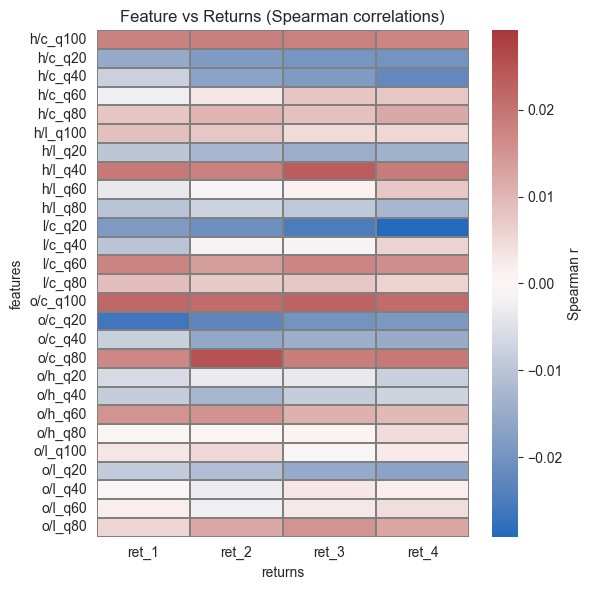

In [150]:
def plot_features_vs_returns_heatmap():

    df = df_new_15m.copy()
    # ensure numeric, drop completely empty rows/cols
    df = df.astype(float)
    df = df.dropna(how='all')          # drop features with no data
    df = df.dropna(axis=1, how='all')  # drop returns with no data
    if df.empty:
        print("No data to plot after dropping all-NaN rows/cols.")
        return

    # symmetric color scale around zero
    vmax = np.nanmax(np.abs(df.values))
    vmin = -vmax

    # figure size: narrow width (few return cols), tall height for many features
    figsize = (max(4, df.shape[1] * 1.5), max(6, int(df.shape[0] * 0.18)))

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")
    sns.heatmap(df, cmap='vlag', center=0, vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Spearman r'}, linewidths=0.25, linecolor='gray')
    plt.xlabel('returns')
    plt.ylabel('features')
    plt.title('Feature vs Returns (Spearman correlations)')
    plt.tight_layout()
    plt.show()

# call it (uses df_new_15m if available)
plot_features_vs_returns_heatmap()

In [151]:
q_levels = [0.2, 0.4, 0.6, 0.8, 1.0]

# prefer the actual returns series (df_audusd_15m). If not present, try df_audusd_5m or raise.
s = df_audusd_15m['ret_1'].dropna()

thresholds = s.quantile(q_levels)
print("ret_1 quantile thresholds:")
print(thresholds)

ret_1 quantile thresholds:
0.2   -0.000399
0.4    0.000000
0.6    0.000000
0.8    0.000410
1.0    0.027014
Name: ret_1, dtype: float64


In [ ]:
# create one-hot bins for ret_1 using quantile thresholds
q_levels = [0.2, 0.4, 0.6, 0.8, 1.0]

s = df_audusd_15m['ret_1']
thresholds = s.quantile(q_levels)
q20, q40, q60, q80, q100 = [thresholds[q] for q in q_levels]

masks = [
    s <= q20,                                 # <= 20%
    (s > q20) & (s <= q40),                   # (20%,40%]
    (s > q40) & (s <= q60),                   # (40%,60%]
    (s > q60) & (s <= q80),                   # (60%,80%]
    (s > q80) & (s <= q100),                  # (80%,100%]
]

names = [f"ret_1_q{int(q*100)}" for q in q_levels]

for name, mask in zip(names, masks):
    # ensure NaNs become 0
    df_audusd_15m[name] = mask.fillna(False).astype(int)

# quick summary
print("Created one-hot columns:", names)
print(df_audusd_15m[names].sum())

Created one-hot columns: ['ret_1_q20', 'ret_1_q40', 'ret_1_q60', 'ret_1_q80', 'ret_1_q100']
ret_1_q20      6083
ret_1_q40     13970
ret_1_q60         0
ret_1_q80      4278
ret_1_q100     6081
dtype: int64


In [162]:
print(f"Quantiles for {col}: q20={q20:.6e}, q40={q40:.6e}, q60={q60:.6e}, q80={q80:.6e}, q100={q100:.6e}")

Quantiles for l/c: q20=-3.993132e-04, q40=0.000000e+00, q60=0.000000e+00, q80=4.097101e-04, q100=2.701407e-02


Rows with ret_1_q20 == 1: 6083


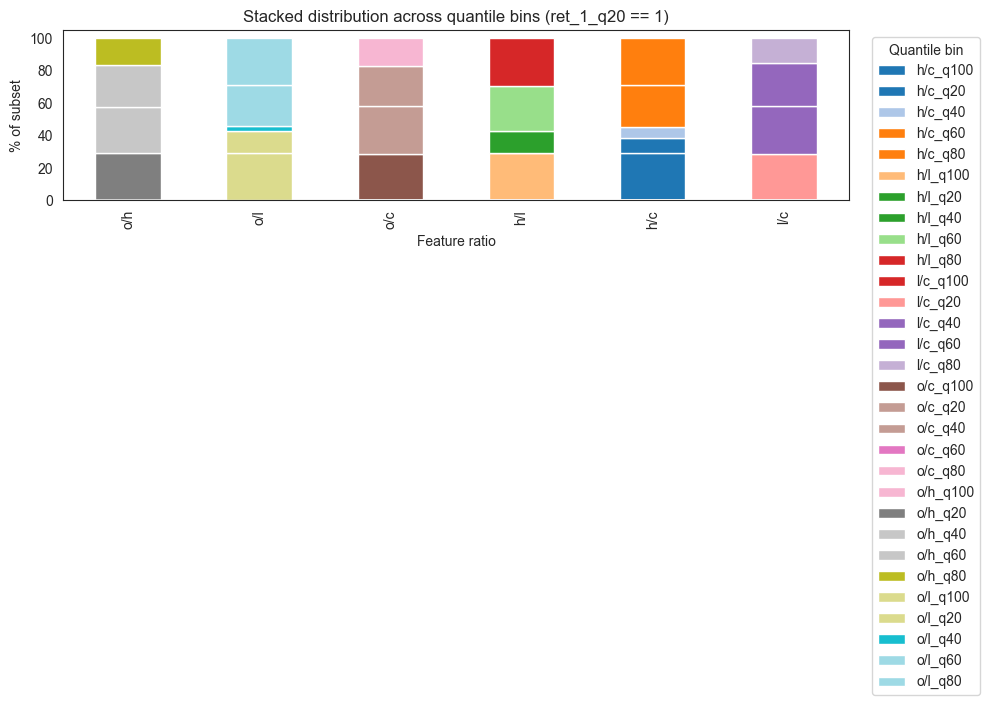

In [155]:
ratio_bases = ['o/h','o/l','o/c','h/l','h/c','l/c']
quantile_labels = [20, 40, 60, 80, 100]

subset = df_audusd_15m[df_audusd_15m['ret_1_q20'] == 1]
n = len(subset)
print(f"Rows with ret_1_q20 == 1: {n}")
if n == 0:
    print("No rows to plot.")
else:
    counts = {}
    pct = {}
    for b in ratio_bases:
        cols = [f"{b}_q{q}" for q in quantile_labels]
        existing = [c for c in cols if c in subset.columns]
        s_counts = subset[existing].sum().astype(int)
        counts[b] = s_counts
        pct[b] = (s_counts / n * 100).round(3)

    df_counts = pd.DataFrame(counts).T.fillna(0).astype(int)
    df_pct = pd.DataFrame(pct).T.fillna(0)

    # Stacked bar chart (each bar = feature ratio, segments = quantile bin %)
    fig, ax = plt.subplots(figsize=(10, 5))
    df_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_ylabel("% of subset")
    ax.set_xlabel("Feature ratio")
    ax.set_title("Stacked distribution across quantile bins (ret_1_q20 == 1)")
    ax.legend(title="Quantile bin", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
l/c_q80
h/c_q60/80
h/l_q80, l/c_q100
o/cq80, o/h_q100
o/lq60
o/hq80

In [ ]:
q_levels = [0.2, 0.4, 0.6, 0.8, 1.0]
ratio_cols = ['o/h','o/l','o/c','h/l','h/c','l/c']

rows = []
missing = []
for col in ratio_cols:
    if col not in df_audusd_15m.columns:
        print(f"Column {col} not found in df_audusd_15m")
        continue
    qv = df_audusd_15m[col].quantile(q_levels)
    rows.append(pd.Series(qv.values, index=['q20','q40','q60','q80','q100'], name=col))

if missing:
    print("Missing ratio columns (skipped):", missing)

if rows:
    thresholds_df = pd.concat(rows, axis=1).T
    # nicer formatting
    pd.options.display.float_format = "{:.6e}".format
    print("Quantile thresholds for df_audusd_15m (rows = ratio, cols = q20..q100):")
    display(thresholds_df)
else:
    print("No ratio columns found to compute thresholds.")

In [157]:
df_audusd_15m.describe()

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,l/c_q20,l/c_q40,l/c_q60,l/c_q80,l/c_q100,ret_1_q20,ret_1_q40,ret_1_q60,ret_1_q80,ret_1_q100
count,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30412.000000,30049.000000,29686.000000,29323.000000,30412.000000,...,30412.000000,30412.000000,30412.000000,30412.000000,30412.0,30412.000000,30412.000000,30412.0,30412.000000,30412.000000
mean,0.919761,0.921068,0.918441,0.919850,0.729054,0.000003,0.000006,0.000009,0.000013,0.998573,...,0.200020,0.199987,0.199987,0.400007,0.0,0.200020,0.459358,0.0,0.140668,0.199954
std,0.048169,0.048024,0.048339,0.048192,0.444455,0.000914,0.001282,0.001552,0.001784,0.002959,...,0.400021,0.399997,0.399997,0.489907,0.0,0.400021,0.498354,0.0,0.347685,0.399972
min,0.806900,0.810300,0.806500,0.807000,0.000000,-0.023909,-0.025370,-0.026588,-0.031354,0.960928,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
25%,0.889400,0.889600,0.888600,0.889400,0.000000,-0.000224,-0.000335,-0.000433,-0.000498,0.998699,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
50%,0.914300,0.915100,0.913500,0.914400,1.000000,0.000000,0.000000,0.000000,0.000000,0.999773,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000
75%,0.965700,0.967100,0.963300,0.965300,1.000000,0.000232,0.000398,0.000495,0.000572,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000
max,1.023300,1.025300,1.023200,1.023400,1.000000,0.027014,0.027257,0.027139,0.026547,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,0.0,1.000000,1.000000


In [158]:
mask = df_audusd_15m['flag'] == 0
if not mask.any():
    print("No rows with flag == 0")
else:
    first_idx = df_audusd_15m.index[mask][0]
    pos = df_audusd_15m.index.get_loc(first_idx)
    start = max(0, pos - 10)
    end = min(len(df_audusd_15m) - 1, pos + 10)
    print(f"First flag==0 at index {first_idx} (position {pos}). Showing rows {start}..{end}:")
    display(df_audusd_15m.iloc[start:end+1])

First flag==0 at index 2010-01-09 03:15:00 (position 424). Showing rows 414..434:


,<OPEN>,<HIGH>,<LOW>,<CLOSE>,flag,ret_1,ret_2,ret_3,ret_4,o/h,...,l/c_q20,l/c_q40,l/c_q60,l/c_q80,l/c_q100,ret_1_q20,ret_1_q40,ret_1_q60,ret_1_q80,ret_1_q100
2010-01-08 21:45:00,0.9165,0.9166,0.9165,0.9165,1.0,0.000109,-0.000218,-0.000109,0.000109,0.999891,...,0,0,0,1,0,0,0,0,1,0
2010-01-08 22:00:00,0.9165,0.9166,0.9165,0.9166,1.0,-0.000327,-0.000218,0.000000,0.000000,0.999891,...,0,0,0,1,0,0,1,0,0,0
2010-01-08 22:15:00,0.9171,0.9171,0.9163,0.9163,1.0,0.000109,0.000327,0.000327,0.000327,1.000000,...,0,0,0,1,0,0,0,0,1,0
2010-01-08 22:30:00,0.9163,0.9164,0.9163,0.9164,1.0,0.000218,0.000218,0.000218,-0.000218,0.999891,...,0,0,0,1,0,0,0,0,1,0
2010-01-08 22:45:00,0.9163,0.9167,0.9163,0.9166,1.0,0.000000,0.000000,-0.000436,-0.000764,0.999564,...,0,0,1,0,0,0,1,0,0,0
2010-01-08 23:00:00,0.9166,0.9166,0.9166,0.9166,1.0,0.000000,-0.000436,-0.000764,-0.001419,1.000000,...,0,0,0,1,0,0,1,0,0,0
2010-01-08 23:15:00,0.9170,0.9170,0.9154,0.9166,1.0,-0.000436,-0.000764,-0.001419,-0.001419,1.000000,...,0,1,0,0,0,1,0,0,0,0
2010-01-08 23:30:00,0.9166,0.9166,0.9162,0.9162,1.0,-0.000327,-0.000983,-0.000983,NaN,1.000000,...,0,0,0,1,0,0,1,0,0,0
2010-01-08 23:45:00,0.9161,0.9163,0.9159,0.9159,1.0,-0.000655,-0.000655,NaN,NaN,0.999782,...,0,0,0,1,0,1,0,0,0,0
2010-01-09 00:00:00,0.9159,0.9160,0.9151,0.9153,1.0,0.000000,NaN,NaN,NaN,0.999891,...,0,0,1,0,0,0,1,0,0,0


In [163]:
df = df_audusd_15m.copy()
feature_cols = [col for col in df.columns if ('_q' in col) and 
                ('o/' in col or 'h/' in col or 'l/' in col)]

target_col = "ret_1_q100"  # top 20% return bin
df_train = df[df["flag"] == 1].copy()

X = df_train[feature_cols]
y = df_train[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced"   # important if buckets are imbalanced
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).head(20))

              precision    recall  f1-score   support

           0       0.79      0.60      0.68      3376
           1       0.28      0.49      0.35      1059

    accuracy                           0.57      4435
   macro avg       0.53      0.54      0.52      4435
weighted avg       0.67      0.57      0.60      4435

l/c_q80     0.055779
o/h_q40     0.052473
o/h_q80     0.049444
h/c_q40     0.047840
o/l_q80     0.045142
h/c_q80     0.045120
o/h_q60     0.044281
o/l_q60     0.043802
h/l_q40     0.041697
o/l_q20     0.041514
l/c_q40     0.041426
h/l_q80     0.040752
h/c_q60     0.040713
l/c_q60     0.040031
o/c_q40     0.039942
h/c_q100    0.039466
h/l_q100    0.037677
h/c_q20     0.036301
h/l_q60     0.030951
o/c_q100    0.029971
dtype: float64


In [166]:
# user-editable paths
parquet_path = './output/test_audusd_15m.parquet'   # adjust if different
# model_path = './output/rf_model.joblib'            # optional saved model

if not os.path.exists(parquet_path):
    raise RuntimeError(f"Parquet file not found: {parquet_path}")

df_test = pd.read_parquet(parquet_path)
print(f"Loaded test parquet: {parquet_path}  rows={len(df_test)} columns={df_test.shape[1]}")

# prepare features same way as training pipeline (expects one-hot quantile feature columns present)
feature_cols = [col for col in df_test.columns if ('_q' in col) and ('o/' in col or 'h/' in col or 'l/' in col)]
target_col = "ret_1_q100"   # same target used during training

if target_col not in df_test.columns:
    raise RuntimeError(f"Target column '{target_col}' not found in test dataset")

if not feature_cols:
    raise RuntimeError("No feature one-hot columns found in test dataset (expected columns with '_q' for o/, h/ or l/).")

# restrict to original-data rows if desired (flag==1)
if 'flag' in df_test.columns:
    df_eval = df_test[df_test['flag'] == 1].copy()
else:
    df_eval = df_test.copy()

X_test = df_eval[feature_cols].fillna(0)
y_test = df_eval[target_col].astype(int).fillna(0)

# load model if saved; otherwise expect `rf` in globals (from training cell)
if 'rf' in globals():
    rf_model = rf
    print("Using rf model from notebook globals")
else:
    raise RuntimeError(f"No model found. Save trained model to model_path or ensure `rf` is in notebook globals.")

# predict and report
y_pred = rf_model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

# optional: save predictions alongside test index
out_dir = './output'
os.makedirs(out_dir, exist_ok=True)
pred_df = df_eval[[*feature_cols]].copy()
pred_df['y_true'] = y_test
pred_df['y_pred'] = y_pred
pred_df.to_parquet(os.path.join(out_dir, 'test_with_predictions.parquet'))
print(f"\nSaved predictions to {os.path.join(out_dir, 'test_with_predictions.parquet')}")

Loaded test parquet: ./output/test_audusd_15m.parquet  rows=697624 columns=50
Using rf model from notebook globals

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.62      0.70    396649
           1       0.25      0.47      0.32    105683

    accuracy                           0.59    502332
   macro avg       0.53      0.54      0.51    502332
weighted avg       0.69      0.59      0.62    502332


Confusion matrix:
[[245075 151574]
 [ 55932  49751]]

Saved predictions to ./output/test_with_predictions.parquet


In [ ]:

# gain_importance = rf.get_score(importance_type='gain')
# print("Feature Importance (Gain):", gain_importance)

# # Get feature importance based on 'cover'
# cover_importance = rf.get_score(importance_type='cover')
print("Feature Importance:", rf.feature_importances_)
print(rf.feature_names_in_)


Feature Importance: [0.02977913 0.0524727  0.04428111 0.0494438  0.         0.0415135
 0.01604439 0.04380232 0.04514211 0.02476296 0.02360775 0.03994186
 0.         0.02636073 0.02997076 0.00962726 0.041697   0.03095078
 0.04075164 0.03767665 0.03630106 0.04783973 0.0407127  0.04511965
 0.03946567 0.02549915 0.04142557 0.04003113 0.05577892 0.        ]
['o/h_q20' 'o/h_q40' 'o/h_q60' 'o/h_q80' 'o/h_q100' 'o/l_q20' 'o/l_q40'
 'o/l_q60' 'o/l_q80' 'o/l_q100' 'o/c_q20' 'o/c_q40' 'o/c_q60' 'o/c_q80'
 'o/c_q100' 'h/l_q20' 'h/l_q40' 'h/l_q60' 'h/l_q80' 'h/l_q100' 'h/c_q20'
 'h/c_q40' 'h/c_q60' 'h/c_q80' 'h/c_q100' 'l/c_q20' 'l/c_q40' 'l/c_q60'
 'l/c_q80' 'l/c_q100']


In [171]:
data = {
    'Features': rf.feature_names_in_,
    'Importance': rf.feature_importances_
}

In [ ]:
pd.DataFrame(data).sort_values(by='Importance', ascending=False)
l/c_q80
h/c_q60/80
h/l_q80, l/c_q100
o/cq80, o/h_q100
o/lq60
o/hq80

,Features,Importance
28,l/c_q80,0.055779
1,o/h_q40,0.052473
3,o/h_q80,0.049444
21,h/c_q40,0.047840
8,o/l_q80,0.045142
23,h/c_q80,0.045120
2,o/h_q60,0.044281
7,o/l_q60,0.043802
16,h/l_q40,0.041697
5,o/l_q20,0.041514


In [177]:
df = df_audusd_15m.copy()
print(df.index)

DatetimeIndex(['2010-01-03 23:15:00', '2010-01-03 23:30:00',
               '2010-01-03 23:45:00', '2010-01-04 00:00:00',
               '2010-01-04 03:15:00', '2010-01-04 03:30:00',
               '2010-01-04 03:45:00', '2010-01-04 04:00:00',
               '2010-01-04 04:15:00', '2010-01-04 04:30:00',
               ...
               '2010-12-31 21:45:00', '2010-12-31 22:00:00',
               '2010-12-31 22:15:00', '2010-12-31 22:30:00',
               '2010-12-31 22:45:00', '2010-12-31 23:00:00',
               '2010-12-31 23:15:00', '2010-12-31 23:30:00',
               '2010-12-31 23:45:00', '2011-01-01 00:00:00'],
              dtype='datetime64[ns]', length=30412, freq=None)


In [ ]:
# df = df_audusd_15m.copy()
feature_cols = [col for col in df.columns if ('_q' in col) and 
                ('o/' in col or 'h/' in col or 'l/' in col)]

target_col = "ret_1_q20"  # bottom 20% return bin
df_train = df[df["flag"] == 1].copy()

X = df_train[feature_cols]
y = df_train[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

rf_ret1q20 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced"   # important if buckets are imbalanced
)

rf_ret1q20.fit(X_train, y_train)

y_pred = rf_ret1q20.predict(X_test)
print(classification_report(y_test, y_pred))

importances = pd.Series(rf_ret1q20.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).head(20))

              precision    recall  f1-score   support

           0       0.76      0.56      0.65      3284
           1       0.29      0.50      0.37      1151

    accuracy                           0.55      4435
   macro avg       0.52      0.53      0.51      4435
weighted avg       0.64      0.55      0.57      4435

h/l_q40     0.066907
l/c_q80     0.053830
o/h_q40     0.048935
o/l_q60     0.047579
o/c_q40     0.046795
h/c_q60     0.046297
h/c_q80     0.044962
o/l_q20     0.043634
o/l_q80     0.042836
l/c_q40     0.042527
h/c_q40     0.041171
h/l_q80     0.040940
o/h_q60     0.038385
l/c_q60     0.038274
h/l_q100    0.035644
h/c_q20     0.034531
o/h_q80     0.034032
o/c_q80     0.033197
h/l_q60     0.029669
h/c_q100    0.029225
dtype: float64


In [180]:
print(importances.sort_values(ascending=False))

h/l_q40     0.066907
l/c_q80     0.053830
o/h_q40     0.048935
o/l_q60     0.047579
o/c_q40     0.046795
h/c_q60     0.046297
h/c_q80     0.044962
o/l_q20     0.043634
o/l_q80     0.042836
l/c_q40     0.042527
h/c_q40     0.041171
h/l_q80     0.040940
o/h_q60     0.038385
l/c_q60     0.038274
h/l_q100    0.035644
h/c_q20     0.034531
o/h_q80     0.034032
o/c_q80     0.033197
h/l_q60     0.029669
h/c_q100    0.029225
o/l_q100    0.028594
o/h_q20     0.025741
o/c_q20     0.025736
l/c_q20     0.023930
o/c_q100    0.022967
o/l_q40     0.021222
h/l_q20     0.012441
o/c_q60     0.000000
o/h_q100    0.000000
l/c_q100    0.000000
dtype: float64


In [184]:
parquet_path = './output/test_audusd_15m.parquet'   # adjust if different
df_test = pd.read_parquet(parquet_path)
# print(df_test.info())
df_test2 = df_test[(df_test.index >= '2013-01-01') & (df_test.index < '2019-01-01')]
print(df_test2.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184044 entries, 2013-01-01 00:00:00 to 2018-12-31 23:45:00
Data columns (total 50 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   <OPEN>      184044 non-null  float64
 1   <HIGH>      184044 non-null  float64
 2   <LOW>       184044 non-null  float64
 3   <CLOSE>     184044 non-null  float64
 4   flag        184044 non-null  int64  
 5   ret_1       184044 non-null  float64
 6   ret_2       184044 non-null  float64
 7   ret_3       184044 non-null  float64
 8   ret_4       184044 non-null  float64
 9   ret_1_q20   184044 non-null  float64
 10  ret_1_q40   184044 non-null  float64
 11  ret_1_q60   184044 non-null  float64
 12  ret_1_q80   184044 non-null  float64
 13  ret_1_q100  184044 non-null  float64
 14  o/h         184044 non-null  float64
 15  o/l         184044 non-null  float64
 16  o/c         184044 non-null  float64
 17  h/l         184044 non-null  float64
 18  h/c       

In [185]:
# prepare features same way as training pipeline (expects one-hot quantile feature columns present)
feature_cols = [col for col in df_test2.columns if ('_q' in col) and ('o/' in col or 'h/' in col or 'l/' in col)]
target_col = "ret_1_q20"   # same target used during training

# restrict to original-data rows if desired (flag==1)
if 'flag' in df_test2.columns:
    df_eval = df_test2[df_test2['flag'] == 1].copy()
else:
    df_eval = df_test2.copy()

X_test = df_eval[feature_cols].fillna(0)
y_test = df_eval[target_col].astype(int).fillna(0)

# load model if saved; otherwise expect `rf` in globals (from training cell)
if 'rf_ret1q20' in globals():
    rf_model = rf_ret1q20
    print("Using rf_ret1q20 model from notebook globals")
else:
    raise RuntimeError(f"No model found. Save trained model to model_path or ensure `rf_ret1q20` is in notebook globals.")

# predict and report
y_pred = rf_model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

# optional: save predictions alongside test index
out_dir = './output'
os.makedirs(out_dir, exist_ok=True)
pred_df = df_eval[[*feature_cols]].copy()
pred_df['y_true'] = y_test
pred_df['y_pred'] = y_pred
pred_df.to_parquet(os.path.join(out_dir, 'test_with_predictions.parquet'))
print(f"\nSaved predictions to {os.path.join(out_dir, 'test_with_predictions.parquet')}")

Using rf_ret1q20 model from notebook globals

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.64      0.72    107042
           1       0.22      0.43      0.29     25309

    accuracy                           0.60    132351
   macro avg       0.52      0.54      0.51    132351
weighted avg       0.71      0.60      0.64    132351


Confusion matrix:
[[68953 38089]
 [14456 10853]]

Saved predictions to ./output/test_with_predictions.parquet


In [202]:
check_pred = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred
})
check_pred['correct'] = (check_pred['y_true'] == check_pred['y_pred']).astype(int)
print(check_pred['correct'].value_counts())

correct
1    79806
0    52545
Name: count, dtype: int64


In [203]:
print(df_test2.loc[df_test2['ret_1_q20'] == 1, ['<CLOSE>', '<OPEN>', '<HIGH>', '<LOW>', 'flag', 'ret_1_q20']].head(10))

                     <CLOSE>  <OPEN>  <HIGH>   <LOW>  flag  ret_1_q20
2013-01-01 18:00:00   1.0405  1.0393  1.0405  1.0393     1        1.0
2013-01-01 22:45:00   1.0394  1.0393  1.0397  1.0390     1        1.0
2013-01-02 03:15:00   1.0479  1.0390  1.0486  1.0389     1        1.0
2013-01-02 04:00:00   1.0481  1.0474  1.0484  1.0394     1        1.0
2013-01-02 05:00:00   1.0465  1.0466  1.0467  1.0389     1        1.0
2013-01-02 06:15:00   1.0479  1.0394  1.0480  1.0393     1        1.0
2013-01-02 07:30:00   1.0481  1.0472  1.0484  1.0472     1        1.0
2013-01-02 09:30:00   1.0496  1.0490  1.0496  1.0486     1        1.0
2013-01-02 10:30:00   1.0494  1.0496  1.0496  1.0410     1        1.0
2013-01-02 10:45:00   1.0489  1.0410  1.0493  1.0409     1        1.0


In [186]:
parquet_path = './output/test_audusd_15m.parquet'   # adjust if different
df_test = pd.read_parquet(parquet_path)
# print(df_test.info())
df_test2 = df_test[(df_test.index >= '2013-01-01') & (df_test.index < '2019-01-01')]
print(df_test2.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 184044 entries, 2013-01-01 00:00:00 to 2018-12-31 23:45:00
Data columns (total 50 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   <OPEN>      184044 non-null  float64
 1   <HIGH>      184044 non-null  float64
 2   <LOW>       184044 non-null  float64
 3   <CLOSE>     184044 non-null  float64
 4   flag        184044 non-null  int64  
 5   ret_1       184044 non-null  float64
 6   ret_2       184044 non-null  float64
 7   ret_3       184044 non-null  float64
 8   ret_4       184044 non-null  float64
 9   ret_1_q20   184044 non-null  float64
 10  ret_1_q40   184044 non-null  float64
 11  ret_1_q60   184044 non-null  float64
 12  ret_1_q80   184044 non-null  float64
 13  ret_1_q100  184044 non-null  float64
 14  o/h         184044 non-null  float64
 15  o/l         184044 non-null  float64
 16  o/c         184044 non-null  float64
 17  h/l         184044 non-null  float64
 18  h/c       

In [201]:
# features used during training (one-hot quantile cols for o/, h/, l/)
feature_cols = [col for col in df_test2.columns if ('_q' in col) and ('o/' in col or 'h/' in col or 'l/' in col)]
if not feature_cols:
    raise RuntimeError("No feature columns found (expected one-hot '_q' cols)")

# evaluate only original-data rows
df_eval = df_test2[df_test2['flag'] == 1].copy()
X = df_eval[feature_cols].fillna(0)

# model predictions
pred_long = rf.predict(X)                # rf trained to predict top-decile (ret_1_q100) -> long
pred_short = rf_ret1q20.predict(X)       # rf_ret1q20 trained to predict bottom-decile (ret_1_q20) -> short

# build single signal per row: prefer long if both predict 1
signal = np.zeros(len(X), dtype=int)
signal[(pred_long == 1) & (pred_short != 1)] = -1
signal[(pred_long != 1) & (pred_short == 1)] = 1

# attach signals back to df_eval
df_eval = df_eval.assign(signal=signal)
# keep only executed trades (signal != 0)
trades = df_eval[df_eval['signal'] != 0].copy()
if trades.empty:
    print("No trades signalled.")
else:
    # entry will be next bar (open of next bar); hold for that bar (open -> close)
    trades['signal_time'] = trades.index                       # time when signal was observed
    trades['entry_time'] = trades['signal_time'] + pd.Timedelta(minutes=15)   # next bar timestamp
    trades['exit_time'] = trades['entry_time']                 # exit at same bar's close (same row)
    trades['duration_min'] = 15.0

    # use raw OHLC prices (do NOT use precomputed ret_1)
    # entry price = OPEN of the next bar, exit price = CLOSE of the same next bar
    entry_open = df_eval['<OPEN>'].reindex(trades['entry_time']).values
    exit_close = df_eval['<CLOSE>'].reindex(trades['entry_time']).values

    trades['entry_open'] = entry_open
    trades['exit_close'] = exit_close

    # drop trades where entry or exit price is missing (end of series or missing bar)
    missing = trades['entry_open'].isna() | trades['exit_close'].isna()
    if missing.any():
        nmiss = missing.sum()
        print(f"Dropping {nmiss} trades with missing entry/exit prices.")
        trades = trades[~missing].copy()

    # compute log-return and pct pnl from entry_open -> exit_close
    trades['ret_log_nextbar'] = np.log(trades['exit_close'] / trades['entry_open'])
    trades['pnl_log'] = trades['signal'] * trades['ret_log_nextbar']
    trades['pnl_pct'] = trades['signal'] * (trades['exit_close'] / trades['entry_open'] - 1.0)

    # inventory time series: +1 for long, -1 for short during the next bar interval
    inventory = pd.Series(0, index=df.index)
    for idx, r in trades.iterrows():
        start = r['entry_time']                      # next bar start (we treat index as bar timestamp)
        end = start + pd.Timedelta(minutes=15)       # end of that bar
        mask = (df.index >= start) & (df.index < end)   # include the next bar rows
        inventory.loc[mask] = inventory.loc[mask].add(r['signal'], fill_value=0)

    df['inventory'] = inventory

    # summary stats
    total_trades = len(trades)
    n_long = int((trades['signal'] == 1).sum())
    n_short = int((trades['signal'] == -1).sum())
    total_pnl_log = trades['pnl_log'].sum()
    total_pnl_pct = trades['pnl_pct'].sum()
    avg_duration = trades['duration_min'].mean()

    print(f"Total trades: {total_trades}  (long={n_long}, short={n_short})")
    print(f"Total pnl (log): {total_pnl_log:.6f}, Total pnl (pct): {total_pnl_pct:.6f}")
    print(f"Avg duration (min): {avg_duration:.1f}")

    # save results
    trades_fname = os.path.join(out_dir, 'trades_rf_strategy_15m_nextbar_open_close.parquet')
    trades.to_parquet(trades_fname)
    df_fname = os.path.join(out_dir, 'audusd_15m_with_inventory.parquet')
    df[['inventory']].to_parquet(df_fname)
    print(f"Saved trades -> {trades_fname}")
    print(f"Saved inventory series -> {df_fname}")

    # quick head of trades
    display(trades[['signal_time','entry_time','entry_open','exit_close','duration_min','ret_log_nextbar','pnl_log','pnl_pct']].head(20))


Dropping 663 trades with missing entry/exit prices.
Total trades: 55357  (long=26829, short=28528)
Total pnl (log): 17.294322, Total pnl (pct): 17.200972
Avg duration (min): 15.0
Saved trades -> ./output/trades_rf_strategy_15m_nextbar_open_close.parquet
Saved inventory series -> ./output/audusd_15m_with_inventory.parquet


,signal_time,entry_time,entry_open,exit_close,duration_min,ret_log_nextbar,pnl_log,pnl_pct
2013-01-01 17:30:00,2013-01-01 17:30:00,2013-01-01 17:45:00,1.0393,1.0393,15.0,0.000000,-0.000000,-0.000000
2013-01-01 18:00:00,2013-01-01 18:00:00,2013-01-01 18:15:00,1.0393,1.0393,15.0,0.000000,0.000000,0.000000
2013-01-01 18:15:00,2013-01-01 18:15:00,2013-01-01 18:30:00,1.0400,1.0393,15.0,-0.000673,0.000673,0.000673
2013-01-01 21:30:00,2013-01-01 21:30:00,2013-01-01 21:45:00,1.0393,1.0393,15.0,0.000000,0.000000,0.000000
2013-01-01 23:00:00,2013-01-01 23:00:00,2013-01-01 23:15:00,1.0393,1.0383,15.0,-0.000963,-0.000963,-0.000962
2013-01-01 23:15:00,2013-01-01 23:15:00,2013-01-01 23:30:00,1.0383,1.0391,15.0,0.000770,0.000770,0.000770
2013-01-01 23:30:00,2013-01-01 23:30:00,2013-01-01 23:45:00,1.0393,1.0390,15.0,-0.000289,0.000289,0.000289
2013-01-02 03:30:00,2013-01-02 03:30:00,2013-01-02 03:45:00,1.0395,1.0474,15.0,0.007571,-0.007571,-0.007600
2013-01-02 04:00:00,2013-01-02 04:00:00,2013-01-02 04:15:00,1.0391,1.0470,15.0,0.007574,-0.007574,-0.007603
2013-01-02 04:15:00,2013-01-02 04:15:00,2013-01-02 04:30:00,1.0470,1.0468,15.0,-0.000191,0.000191,0.000191


In [197]:
# features used during training (one-hot quantile cols for o/, h/, l/)
feature_cols = [col for col in df_test2.columns if ('_q' in col) and ('o/' in col or 'h/' in col or 'l/' in col)]
if not feature_cols:
    raise RuntimeError("No feature columns found (expected one-hot '_q' cols)")

# evaluate only original-data rows
df_eval = df_test2[df_test2['flag'] == 1].copy()
X = df_eval[feature_cols].fillna(0)

# model predictions
pred_long = rf.predict(X)                # rf trained to predict top-decile (ret_1_q100) -> long
pred_short = rf_ret1q20.predict(X)       # rf_ret1q20 trained to predict bottom-decile (ret_1_q20) -> short

# build single signal per row: prefer long if both predict 1
signal = np.zeros(len(X), dtype=int)
signal[(pred_long == 1) & (pred_short != 1)] = 1
signal[(pred_long != 1) & (pred_short == 1)] = -1

# attach signals back to df_eval
df_eval = df_eval.assign(signal=signal)
# keep only executed trades (signal != 0)
trades = df_eval[df_eval['signal'] != 0].copy()
if trades.empty:
    print("No trades signalled.")
else:
    # entry will be next bar (open of next bar); hold for that bar (open -> close)
    trades['signal_time'] = trades.index                       # time when signal was observed
    trades['entry_time'] = trades['signal_time'] + pd.Timedelta(minutes=15)   # next bar timestamp
    trades['exit_time'] = trades['entry_time']                 # exit at same bar's close (same row)
    trades['duration_min'] = 15.0

    # use raw OHLC prices (do NOT use precomputed ret_1)
    # entry price = OPEN of the next bar, exit price = CLOSE of the same next bar
    entry_open = df_eval['<OPEN>'].reindex(trades['entry_time']).values
    exit_close = df_eval['<CLOSE>'].reindex(trades['entry_time']).values

    trades['entry_open'] = entry_open
    trades['exit_close'] = exit_close

    # drop trades where entry or exit price is missing (end of series or missing bar)
    missing = trades['entry_open'].isna() | trades['exit_close'].isna()

In [199]:
print(trades)

                     <OPEN>  <HIGH>   <LOW>  <CLOSE>  flag     ret_1  \
2013-01-01 17:30:00  1.0393  1.0404  1.0393   1.0393     1  0.000000   
2013-01-01 18:00:00  1.0393  1.0405  1.0393   1.0405     1 -0.001154   
2013-01-01 18:15:00  1.0393  1.0405  1.0393   1.0393     1  0.000000   
2013-01-01 21:30:00  1.0393  1.0399  1.0392   1.0396     1 -0.000289   
2013-01-01 23:00:00  1.0391  1.0393  1.0379   1.0379     1  0.000385   
...                     ...     ...     ...      ...   ...       ...   
2018-12-28 19:30:00  0.7041  0.7042  0.7038   0.7040     1 -0.000284   
2018-12-28 20:15:00  0.7030  0.7042  0.7030   0.7041     1  0.000000   
2018-12-28 21:15:00  0.7030  0.7041  0.7030   0.7041     1 -0.000142   
2018-12-28 22:15:00  0.7030  0.7040  0.7030   0.7040     1 -0.000142   
2018-12-28 23:15:00  0.7030  0.7041  0.7030   0.7040     1  0.000000   

                        ret_2     ret_3     ret_4  ret_1_q20  ...  l/c_q60  \
2013-01-01 17:30:00  0.001154  0.000000  0.000000        

In [196]:
out_dir = './output'
os.makedirs(out_dir, exist_ok=True)

if 'df_eval' not in globals():
    raise RuntimeError("df_eval not found. Run prior cells that create df_eval before exporting.")

# export first 2000 rows (or fewer if not available)
fname = os.path.join(out_dir, 'df_eval_first_2000.xlsx')
df_eval.head(2000).to_excel(fname, index=True)
print(f"Saved first {min(2000, len(df_eval))} rows of df_eval to {fname}")

Saved first 2000 rows of df_eval to ./output/df_eval_first_2000.xlsx
